# Week 2：问题导向 EDA 与假设验证

基于 Telco 公开代理数据，执行冻结的八周项目 W2 范围。

20 张图表，7 项完成分析并形成结论，另 3 项说明不可验证。所有比例是静态快照已观察流失率，不是未来风险预测。

复现：从项目根目录运行 `.venv/Scripts/python.exe scripts/run_week2.py --verify-reproducibility`。首次环境准备参见交付目录 README；选择 **Python 3.12 (Azure W2)** 内核后可 Restart & Run All。

## D1：数据合同与分析口径

1. 主键客户粒度，原始输入 7,043×21，以 W1 SHA-256 冻结版本。
2. 六项服务：OnlineSecurity、OnlineBackup、DeviceProtection、TechSupport、StreamingTV、StreamingMovies。H4 主分析为互联网客户，保留全体及 DSL/光纤敏感性。
3. tenure 分箱左闭右开：[0,6)、[6,12)、[12,24)、[24,48)、[48,73)。
4. 高月费≥全样本中位数70.35；少服务≤2。风险规则为月付且tenure<6，不使用标签计算个体风险。
5. TotalCharges 只检查空白，不转数值或加入分析。分箱和计数是临时分析变量，不输出客户特征表。
6. 双侧检验，α=.05；6项主检验、6项服务检验、4项人口检验、6项敏感性检验分别 Bonferroni 校正。比例区间为逐组 Wilson 95%，非同时区间；格内 n<30 标*。

In [1]:
from pathlib import Path
import sys
start = Path.cwd().resolve()
candidates = [start, *start.parents]
PACKAGE = next(p for p in candidates if (p / 'src/w2_analysis.py').is_file())
sys.path.insert(0, str(PACKAGE))
from src.w2_analysis import load_data, analyze, plot_all, hypothesis_results, SEED
import numpy as np
from IPython.display import display, Markdown, Image
np.random.seed(SEED)
raw, df, source, fee_edges = load_data()
print(f'数据形状：{raw.shape}；流失：{df.churn.sum()}/{len(df)}（{df.churn.mean():.2%}）；seed={SEED}')
print('月费分位边界：', fee_edges.tolist())
display(raw.dtypes.rename('dtype').to_frame())
display(df[['tenure', 'MonthlyCharges']].describe())

数据形状：(7043, 21)；流失：1869/7043（26.54%）；seed=42
月费分位边界： [18.25, 35.5, 70.35, 89.85, 118.75]


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


## D2–D4：执行统计与生成图表

核心逻辑复用于 `src/w2_analysis.py`，Notebook 负责编排、展示与解释。表格保留样本量、流失人数、比例及区间；分析仅导出聚合结果。

In [2]:
result = analyze()
chart_index = plot_all(result)
hypotheses = hypothesis_results(result)
display(result['tests'][['test_id','n','method','effect_name','effect','p_value','p_bonferroni']])

,test_id,n,method,effect_name,effect,p_value,p_bonferroni
0,service_OnlineSecurity,5517,Pearson chi-square (no Yates),Cramers V,0.280816,1.287900e-96,7.727398e-96
1,service_OnlineBackup,5517,Pearson chi-square (no Yates),Cramers V,0.196061,4.847353e-48,2.908412e-47
2,service_DeviceProtection,5517,Pearson chi-square (no Yates),Cramers V,0.177125,1.567242e-39,9.403450e-39
3,service_TechSupport,5517,Pearson chi-square (no Yates),Cramers V,0.274422,2.362359e-92,1.417416e-91
4,service_StreamingTV,5517,Pearson chi-square (no Yates),Cramers V,0.037057,5.914561e-03,3.548737e-02
5,service_StreamingMovies,5517,Pearson chi-square (no Yates),Cramers V,0.040132,2.874148e-03,1.724489e-02
6,demographic_gender,7043,Pearson chi-square (no Yates),Cramers V,0.008612,4.698339e-01,1.000000e+00
7,demographic_SeniorCitizen,7043,Pearson chi-square (no Yates),Cramers V,0.150889,9.477904e-37,3.791161e-36
8,demographic_Partner,7043,Pearson chi-square (no Yates),Cramers V,0.150448,1.519037e-36,6.076146e-36
9,demographic_Dependents,7043,Pearson chi-square (no Yates),Cramers V,0.164221,3.276083e-43,1.310433e-42


## D2：六张单变量分布

### 图01：流失标签分布（基础）

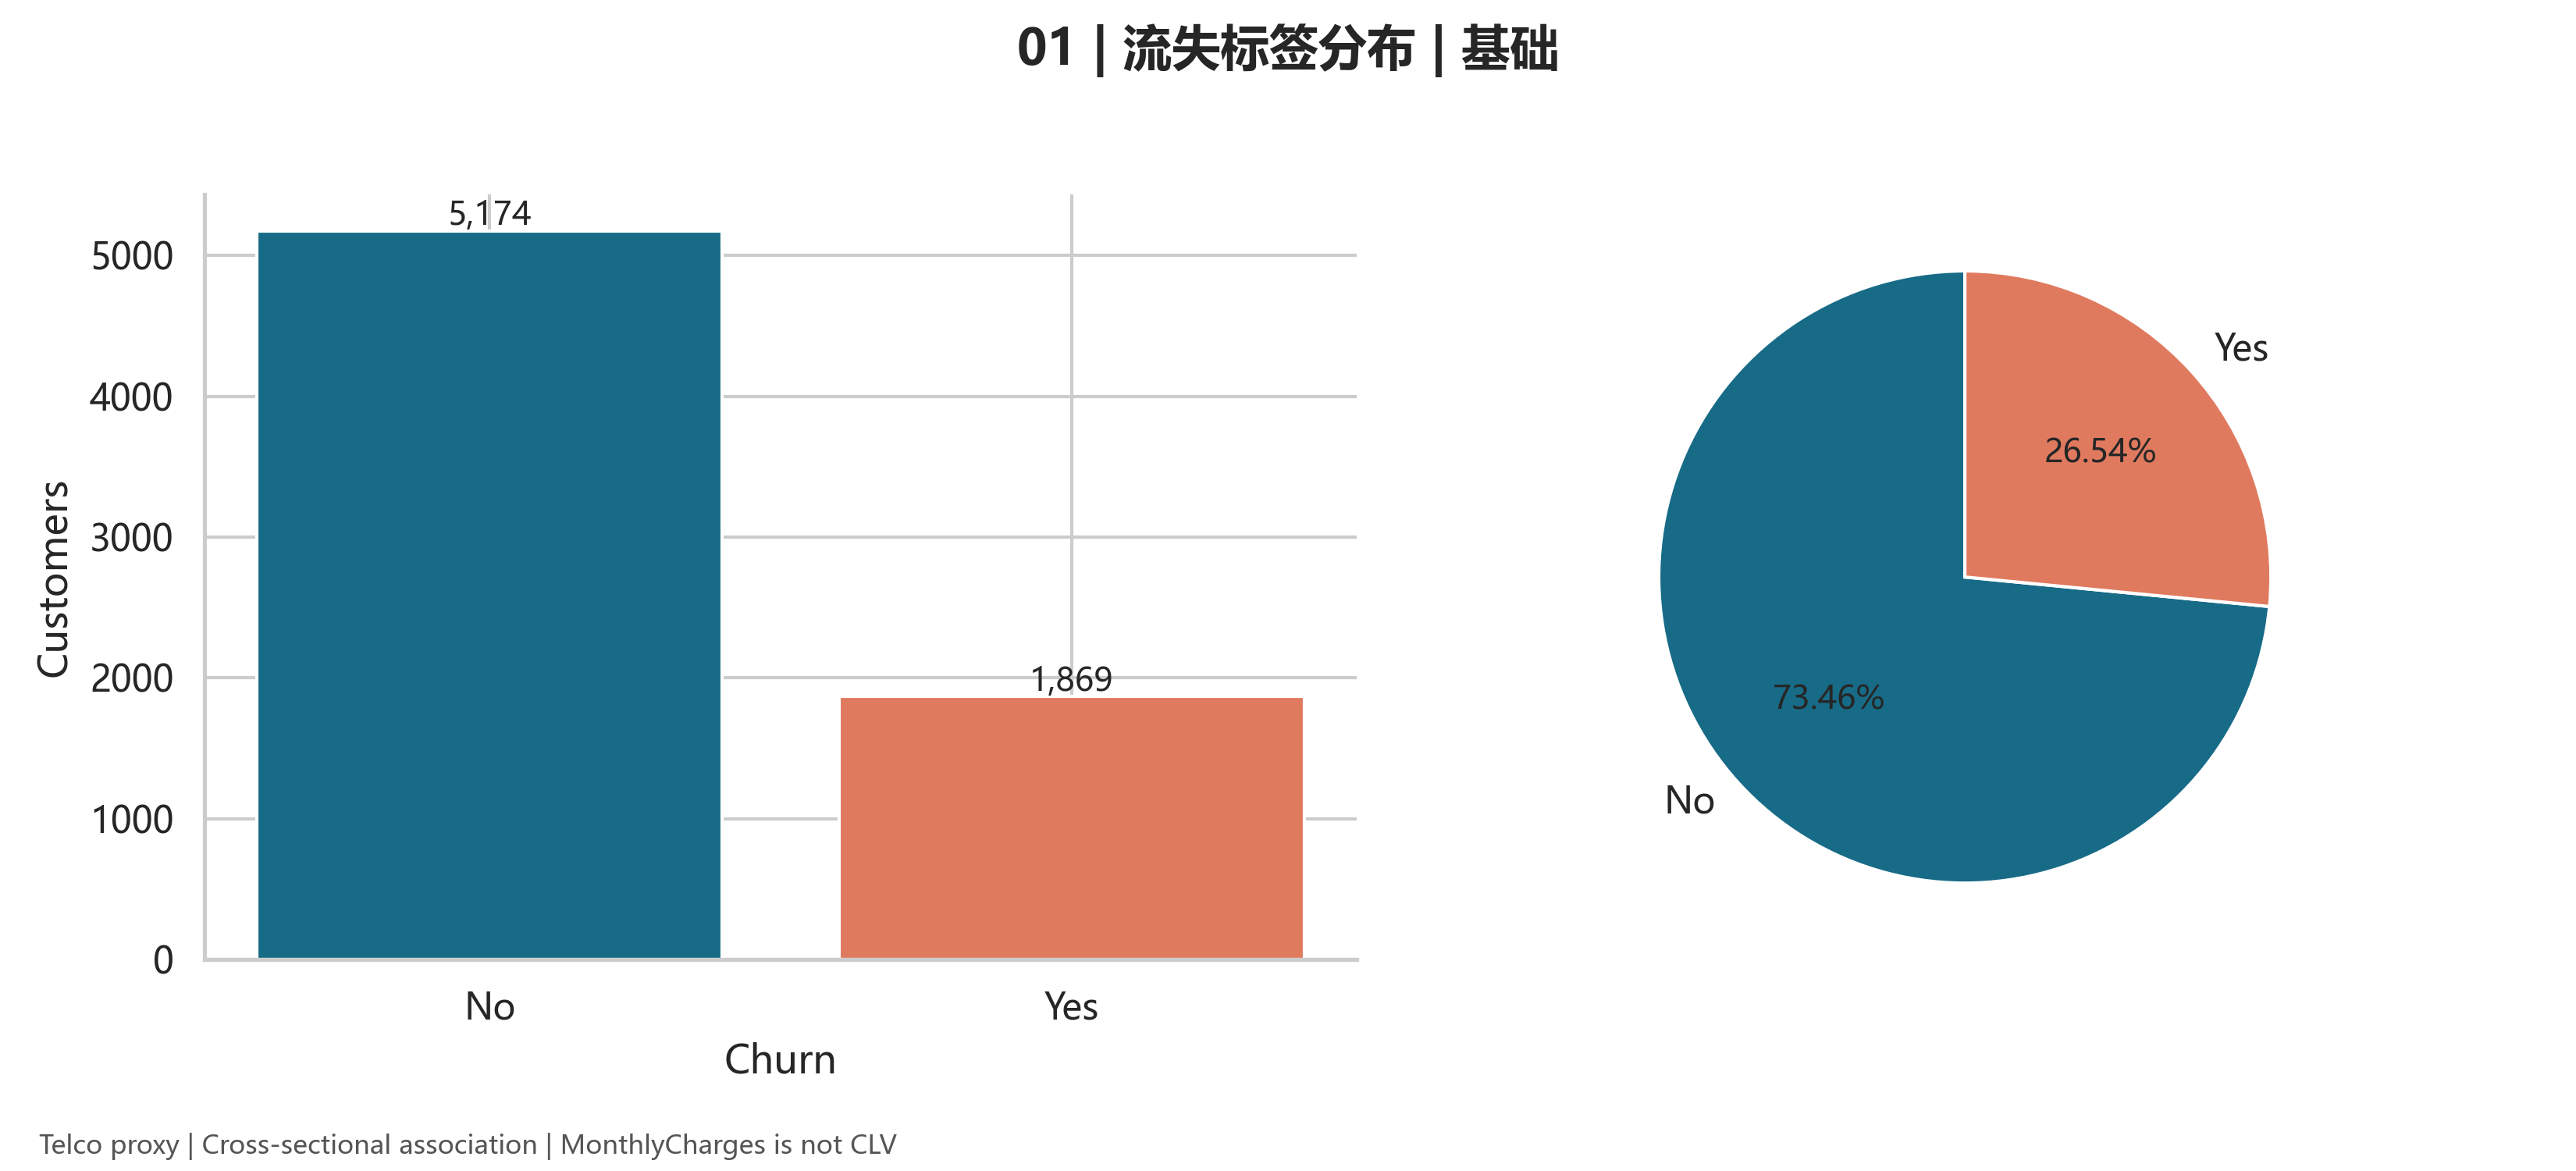

**结论：** 流失1,869/7,043（26.54%）。

**下一步：** 后续评估保留类别占比基线。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_churn_distribution.csv`

In [3]:
chart = chart_index.loc[chart_index.chart_id.eq('01')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图02：客户年限分布（H2）

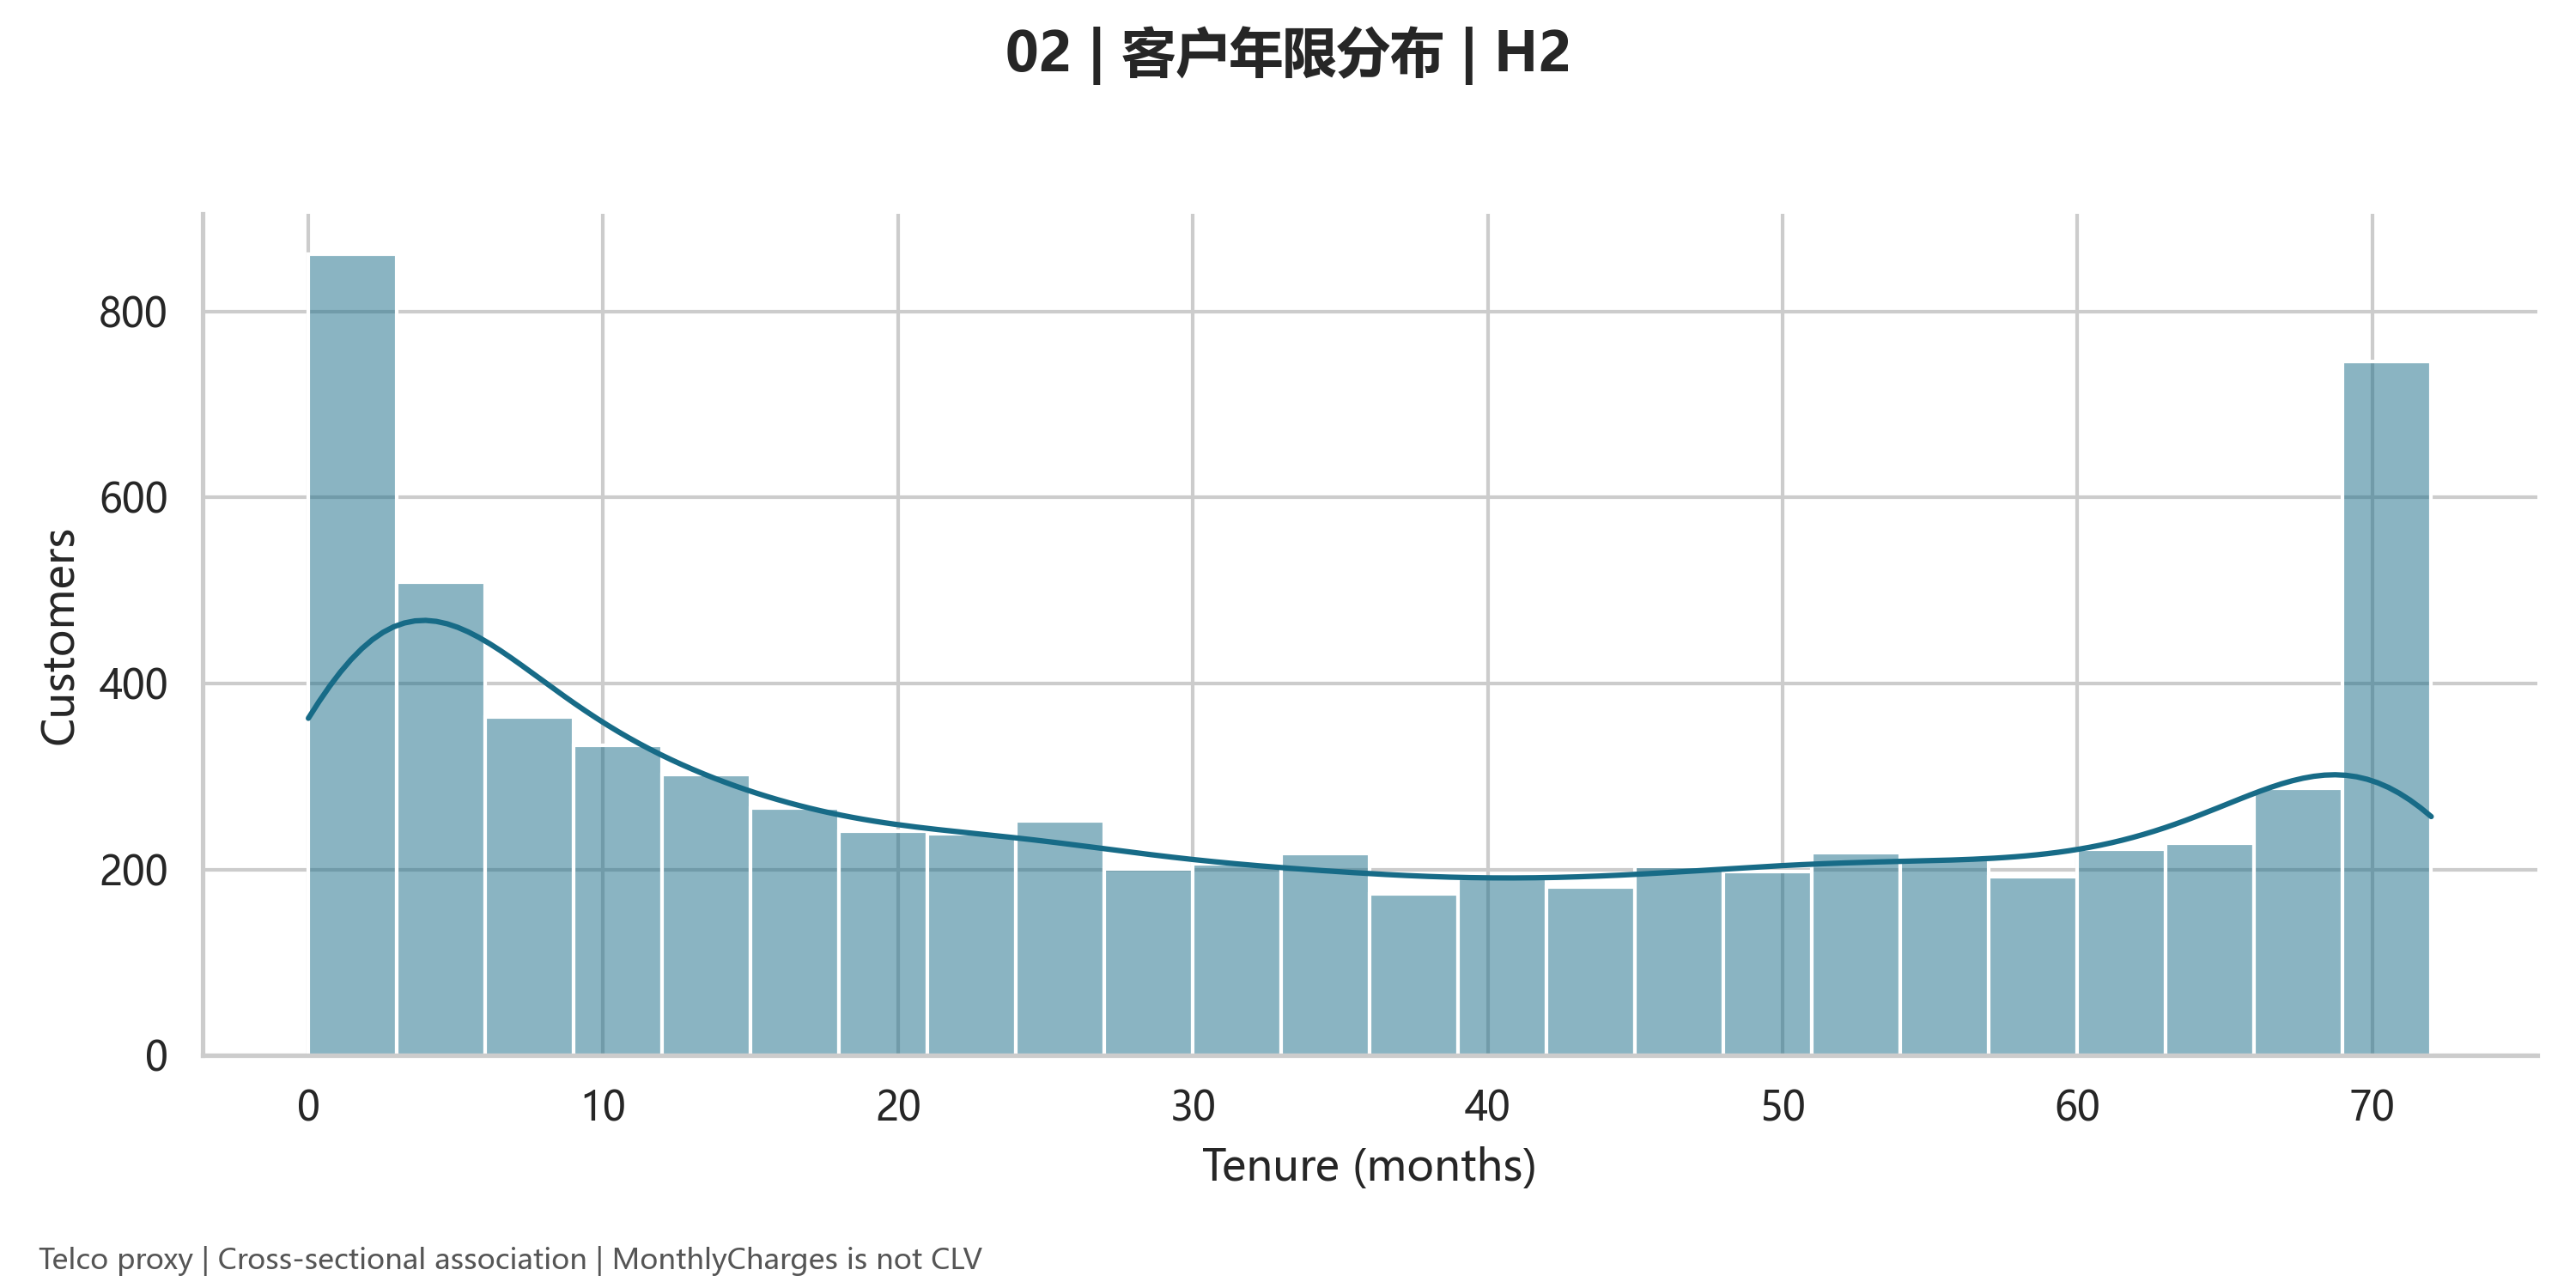

**结论：** tenure<6客户占19.47%；0月客户11名。

**下一步：** 新客分层使用明确的左闭右开月数区间。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_tenure_rates.csv`

In [4]:
chart = chart_index.loc[chart_index.chart_id.eq('02')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图03：月费分布（H10,H5）

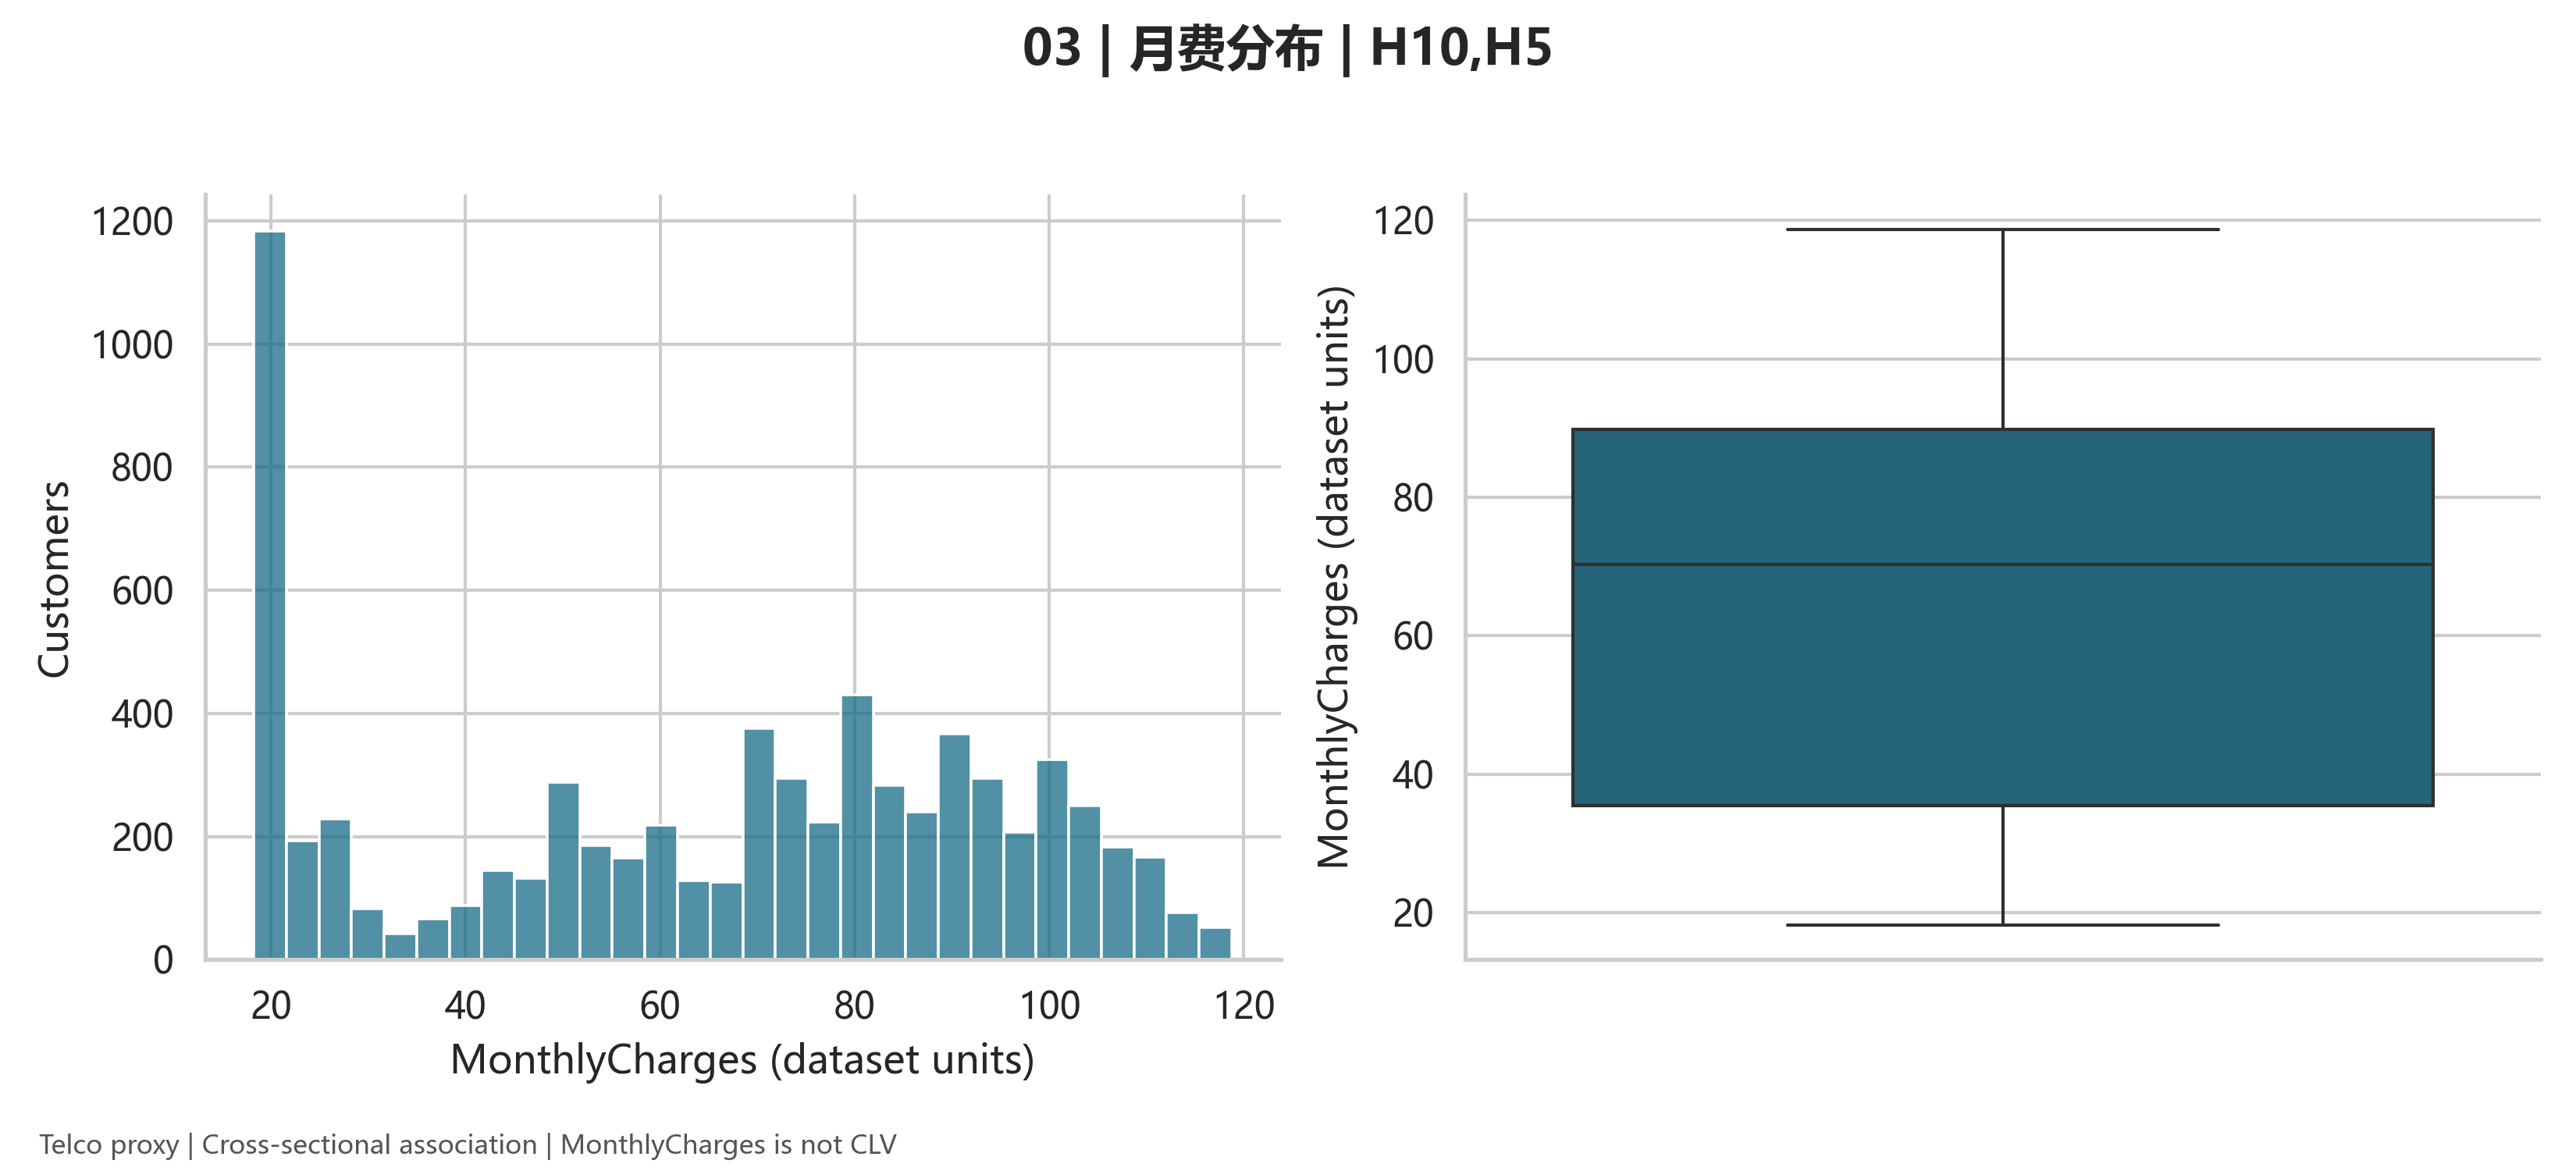

**结论：** 月费中位数70.35，范围18.25–118.75。

**下一步：** 以中位数划分价值代理，货币单位不作额外推断。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_numeric_summary.csv`

In [5]:
chart = chart_index.loc[chart_index.chart_id.eq('03')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图04：Contract客户构成（H1）

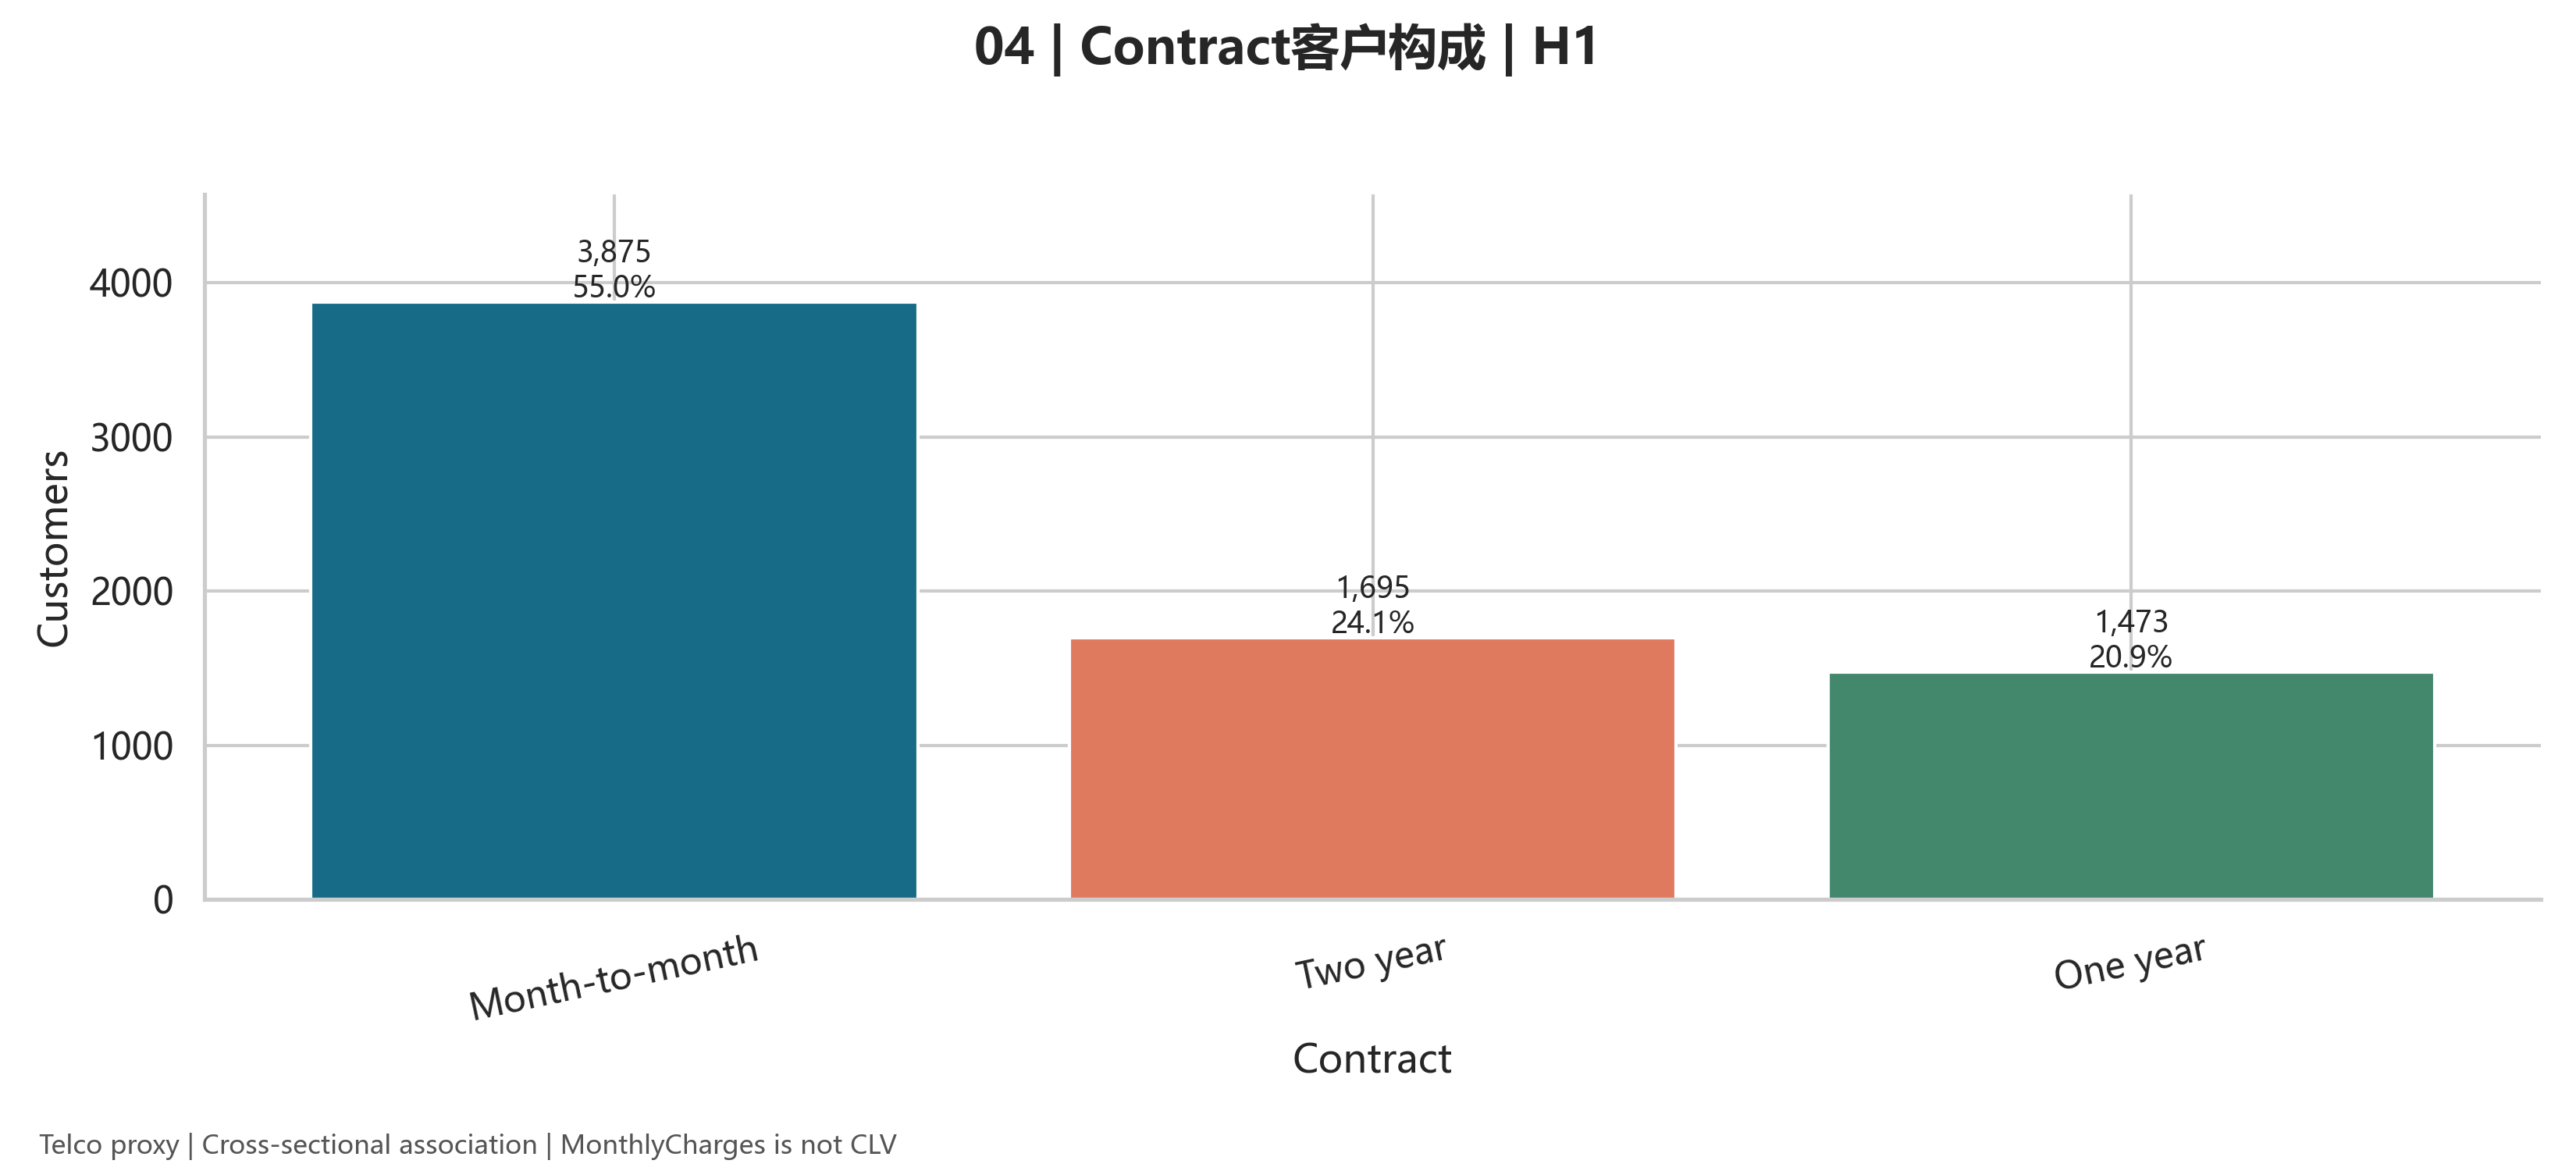

**结论：** 最多类别为Month-to-month，共3,875名。

**下一步：** 结合各组样本量解读后续流失率差异。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_contract_rates.csv`

In [6]:
chart = chart_index.loc[chart_index.chart_id.eq('04')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图05：PaymentMethod客户构成（H6）

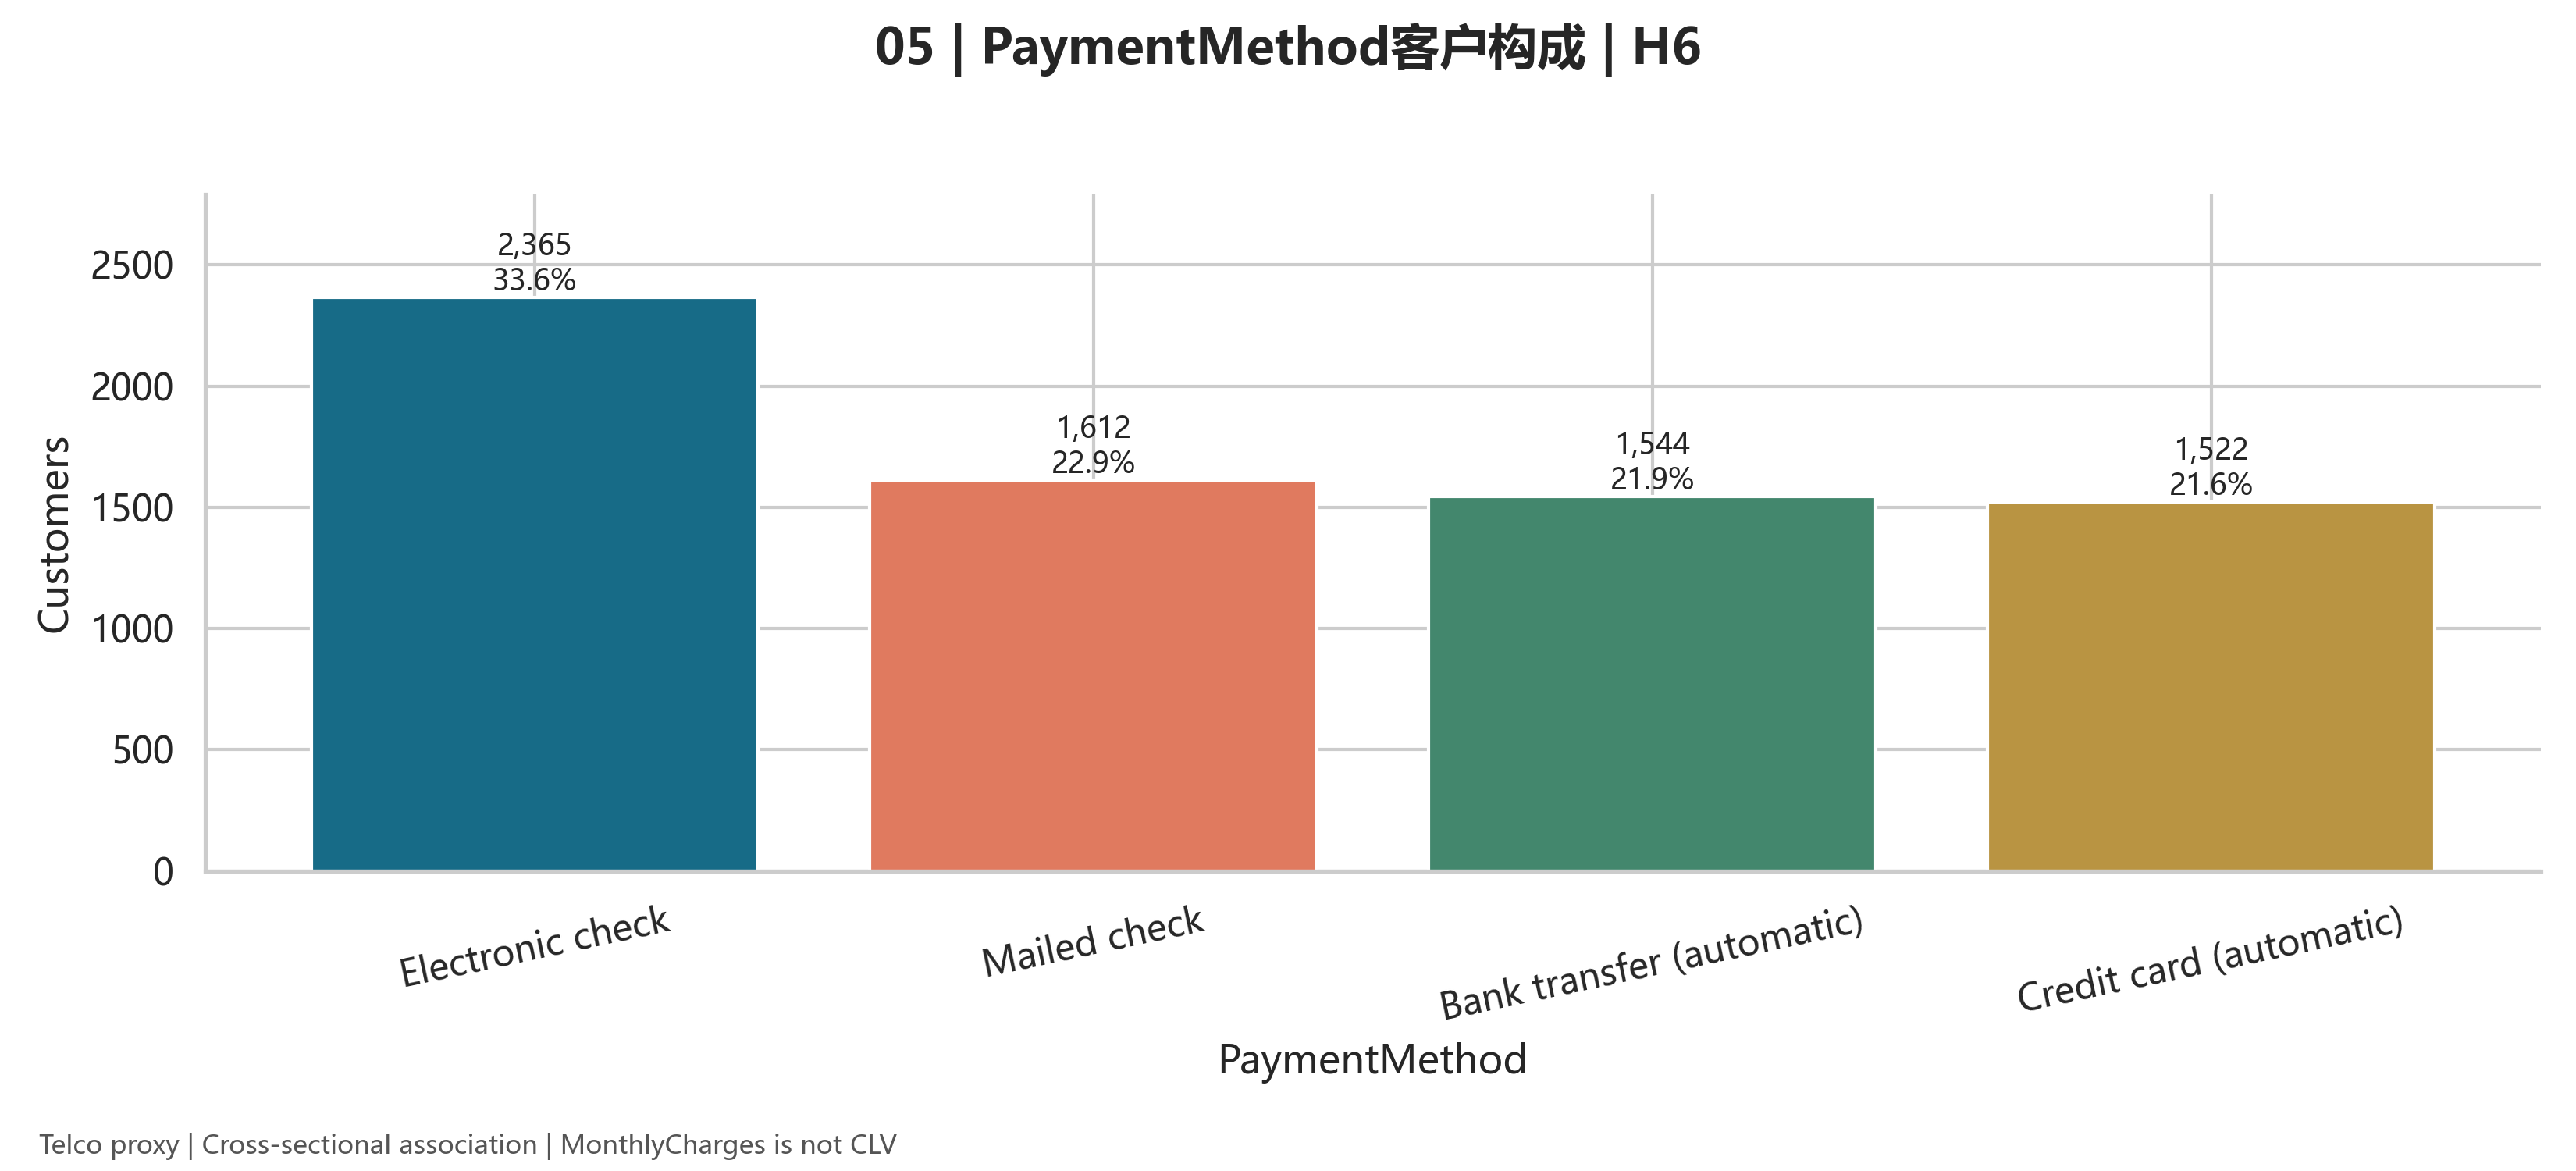

**结论：** 最多类别为Electronic check，共2,365名。

**下一步：** 结合各组样本量解读后续流失率差异。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_payment_rates.csv`

In [7]:
chart = chart_index.loc[chart_index.chart_id.eq('05')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图06：六项互联网增值服务采用率（H4）

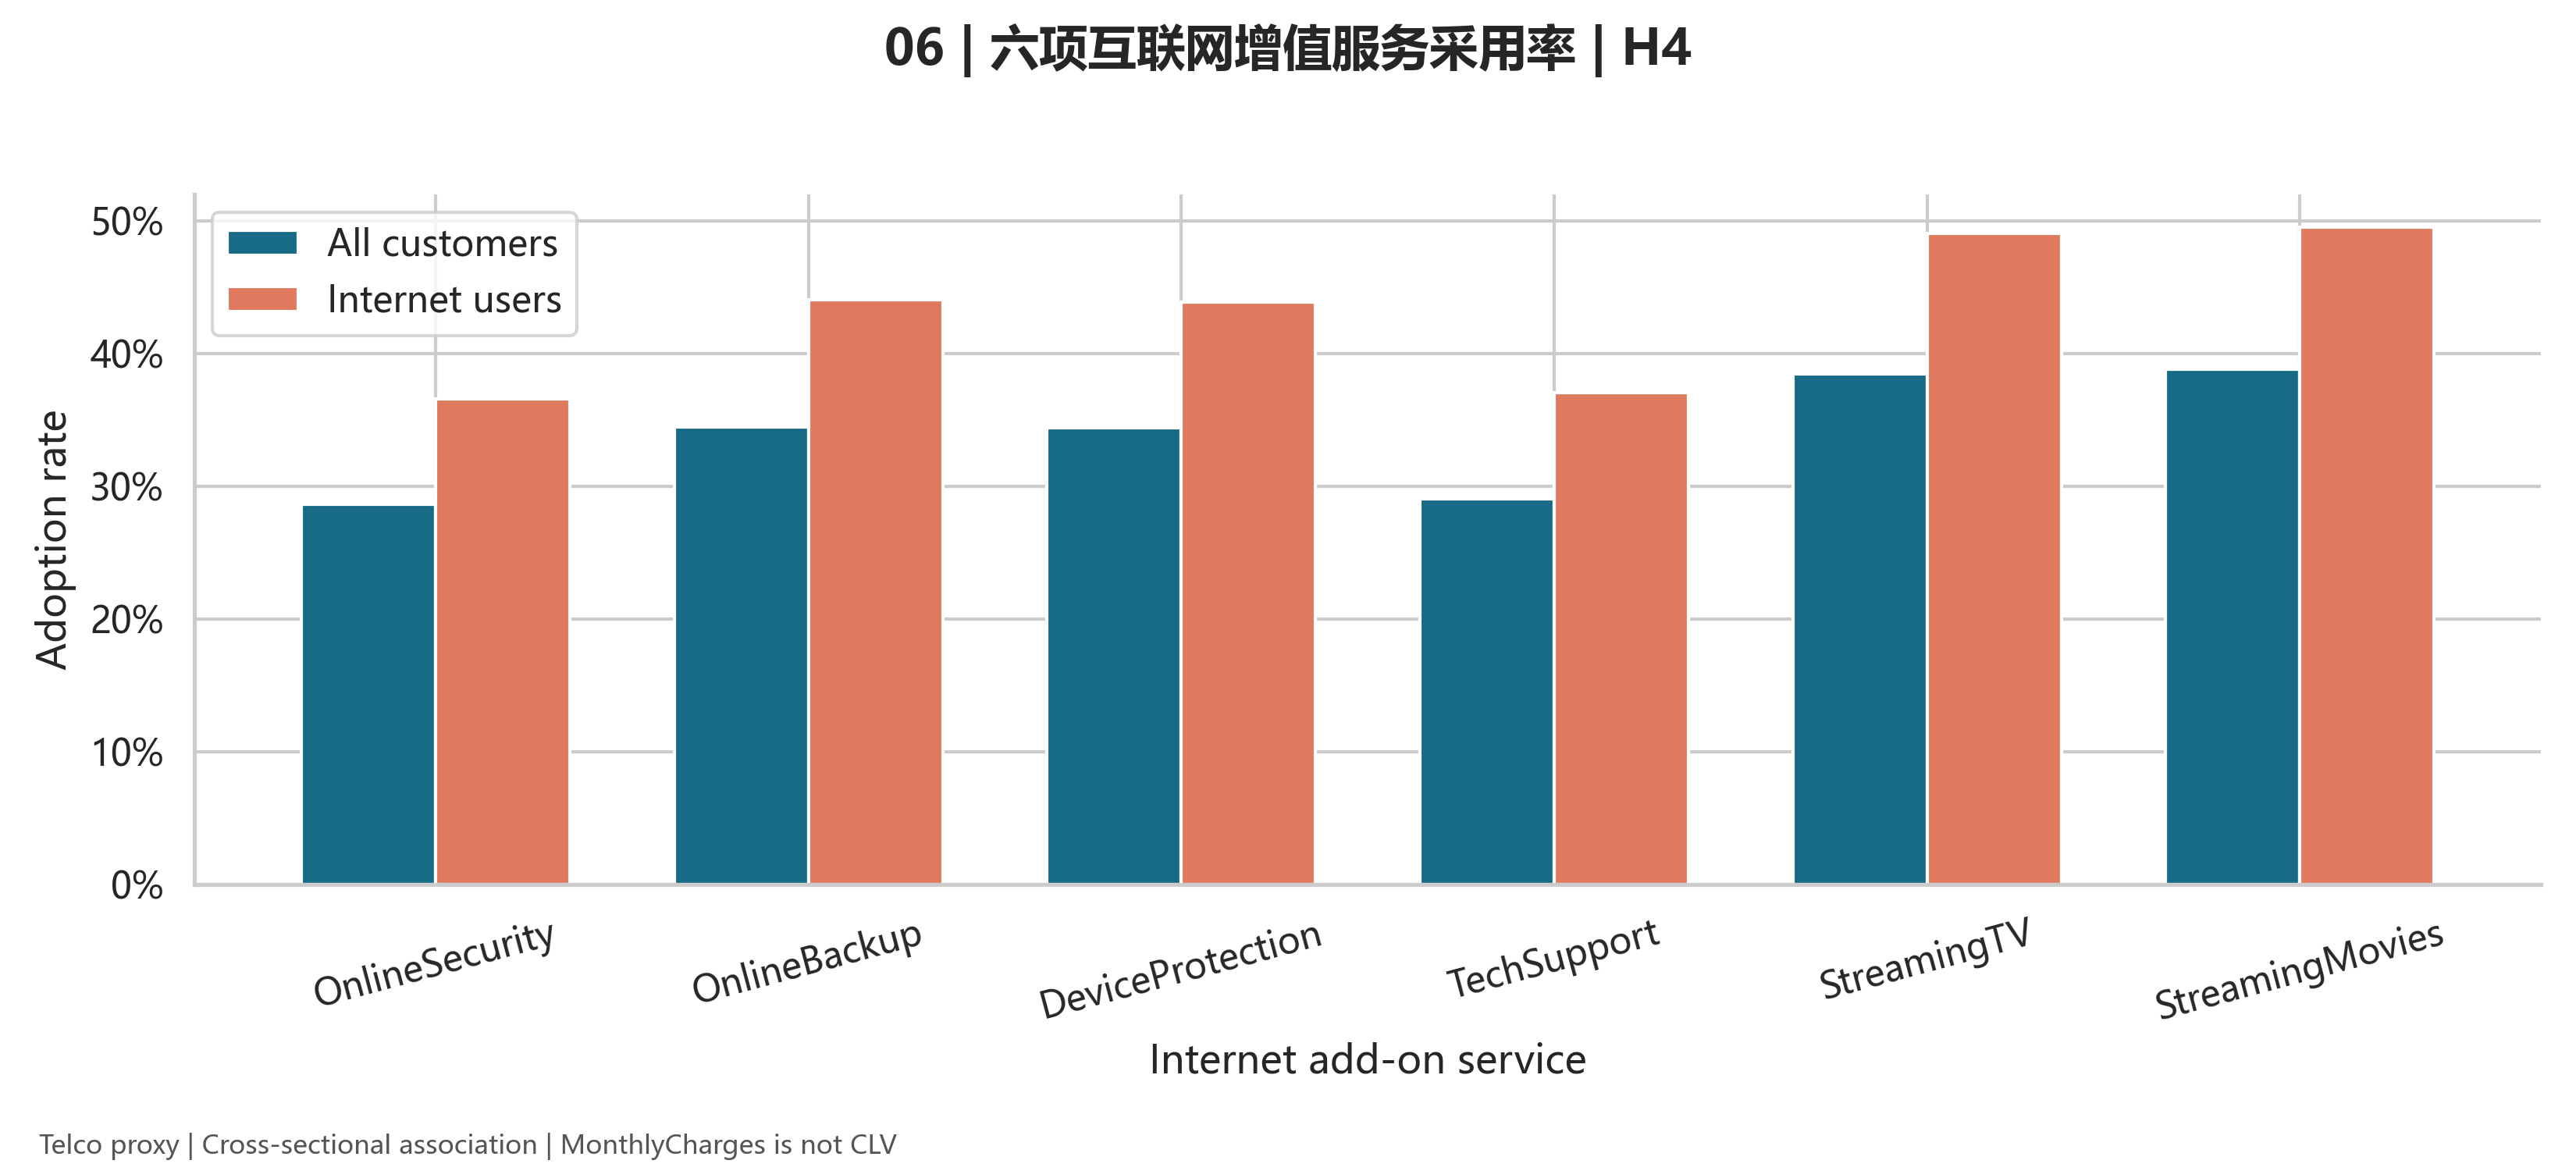

**结论：** 无互联网客户不具备采用六项增值服务的条件，分母会影响采用率。

**下一步：** 服务采用报告同时标明全体与互联网客户分母。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_service_adoption.csv`

In [8]:
chart = chart_index.loc[chart_index.chart_id.eq('06')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

## D2：合同与客户年限假设

### 图07：合同类型与流失率（H1）

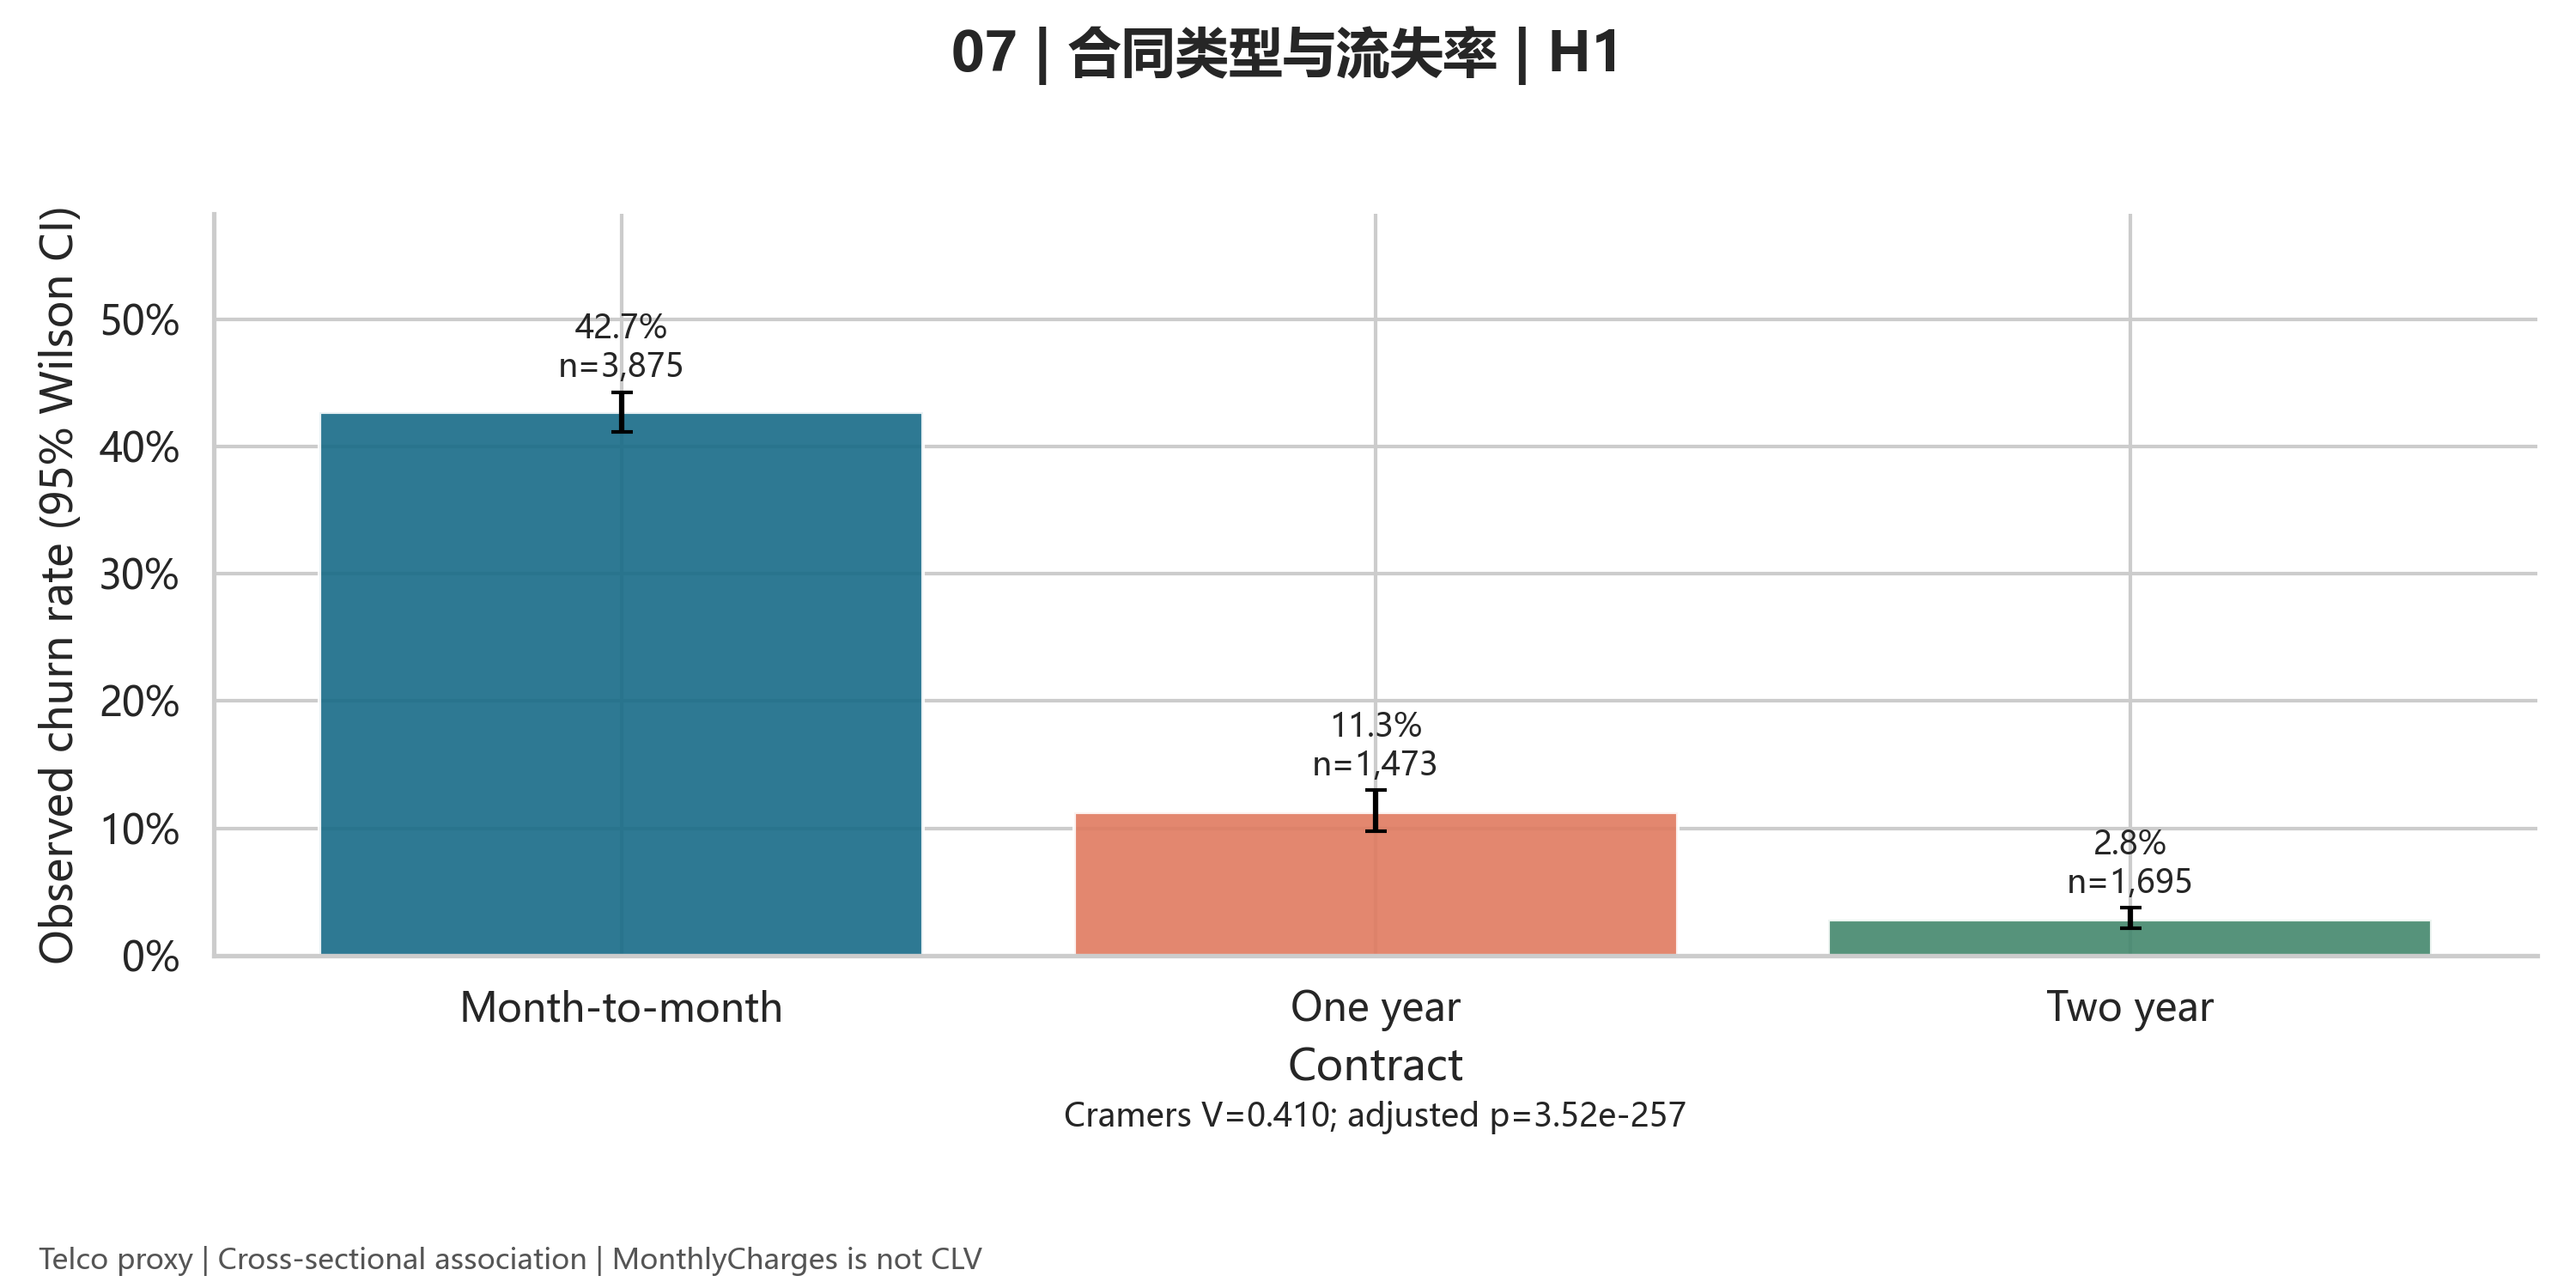

**结论：** Month-to-month 42.71%；One year 11.27%；Two year 2.83%。

**下一步：** 将月付客户列为进一步访谈候选，年付转换效果尚需验证。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_contract_rates.csv`

In [9]:
chart = chart_index.loc[chart_index.chart_id.eq('07')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图08：客户年限与流失率（H2）

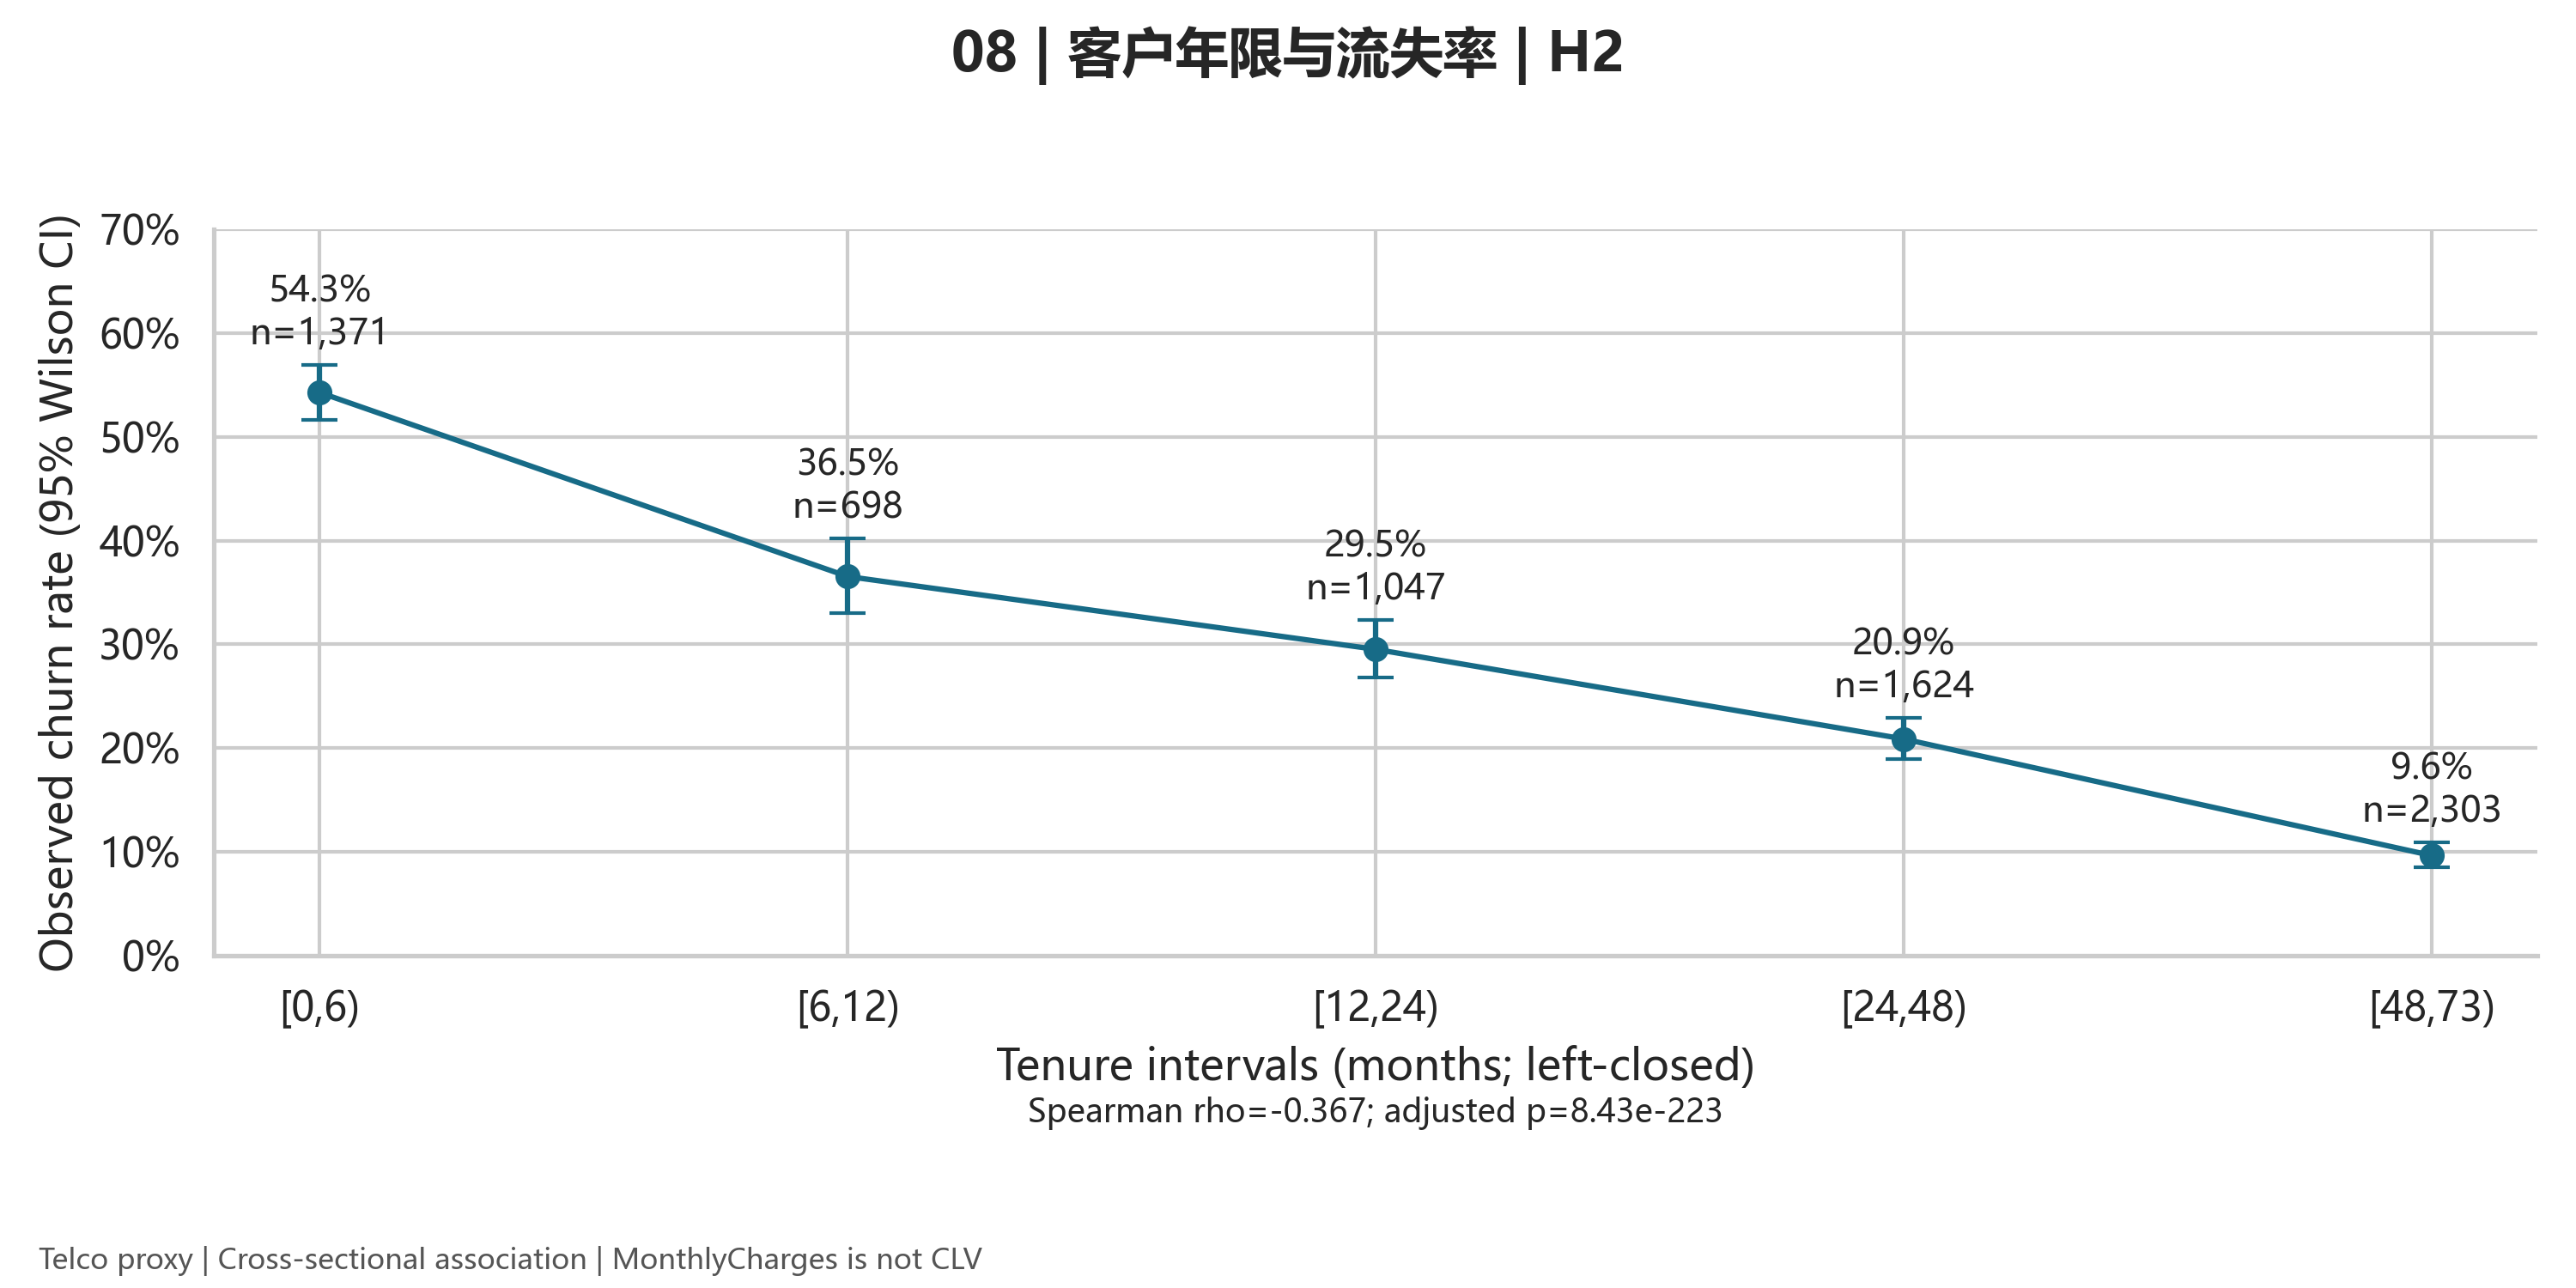

**结论：** [0,6)月组54.27%，[48,73)月组9.64%。

**下一步：** 优先研究上手体验；横截面不能解释为同一批客户的时间趋势。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_tenure_rates.csv`

In [10]:
chart = chart_index.loc[chart_index.chart_id.eq('08')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

## D3：服务采用、费用与支付方式

### 图09：增值服务数与流失率（H4）

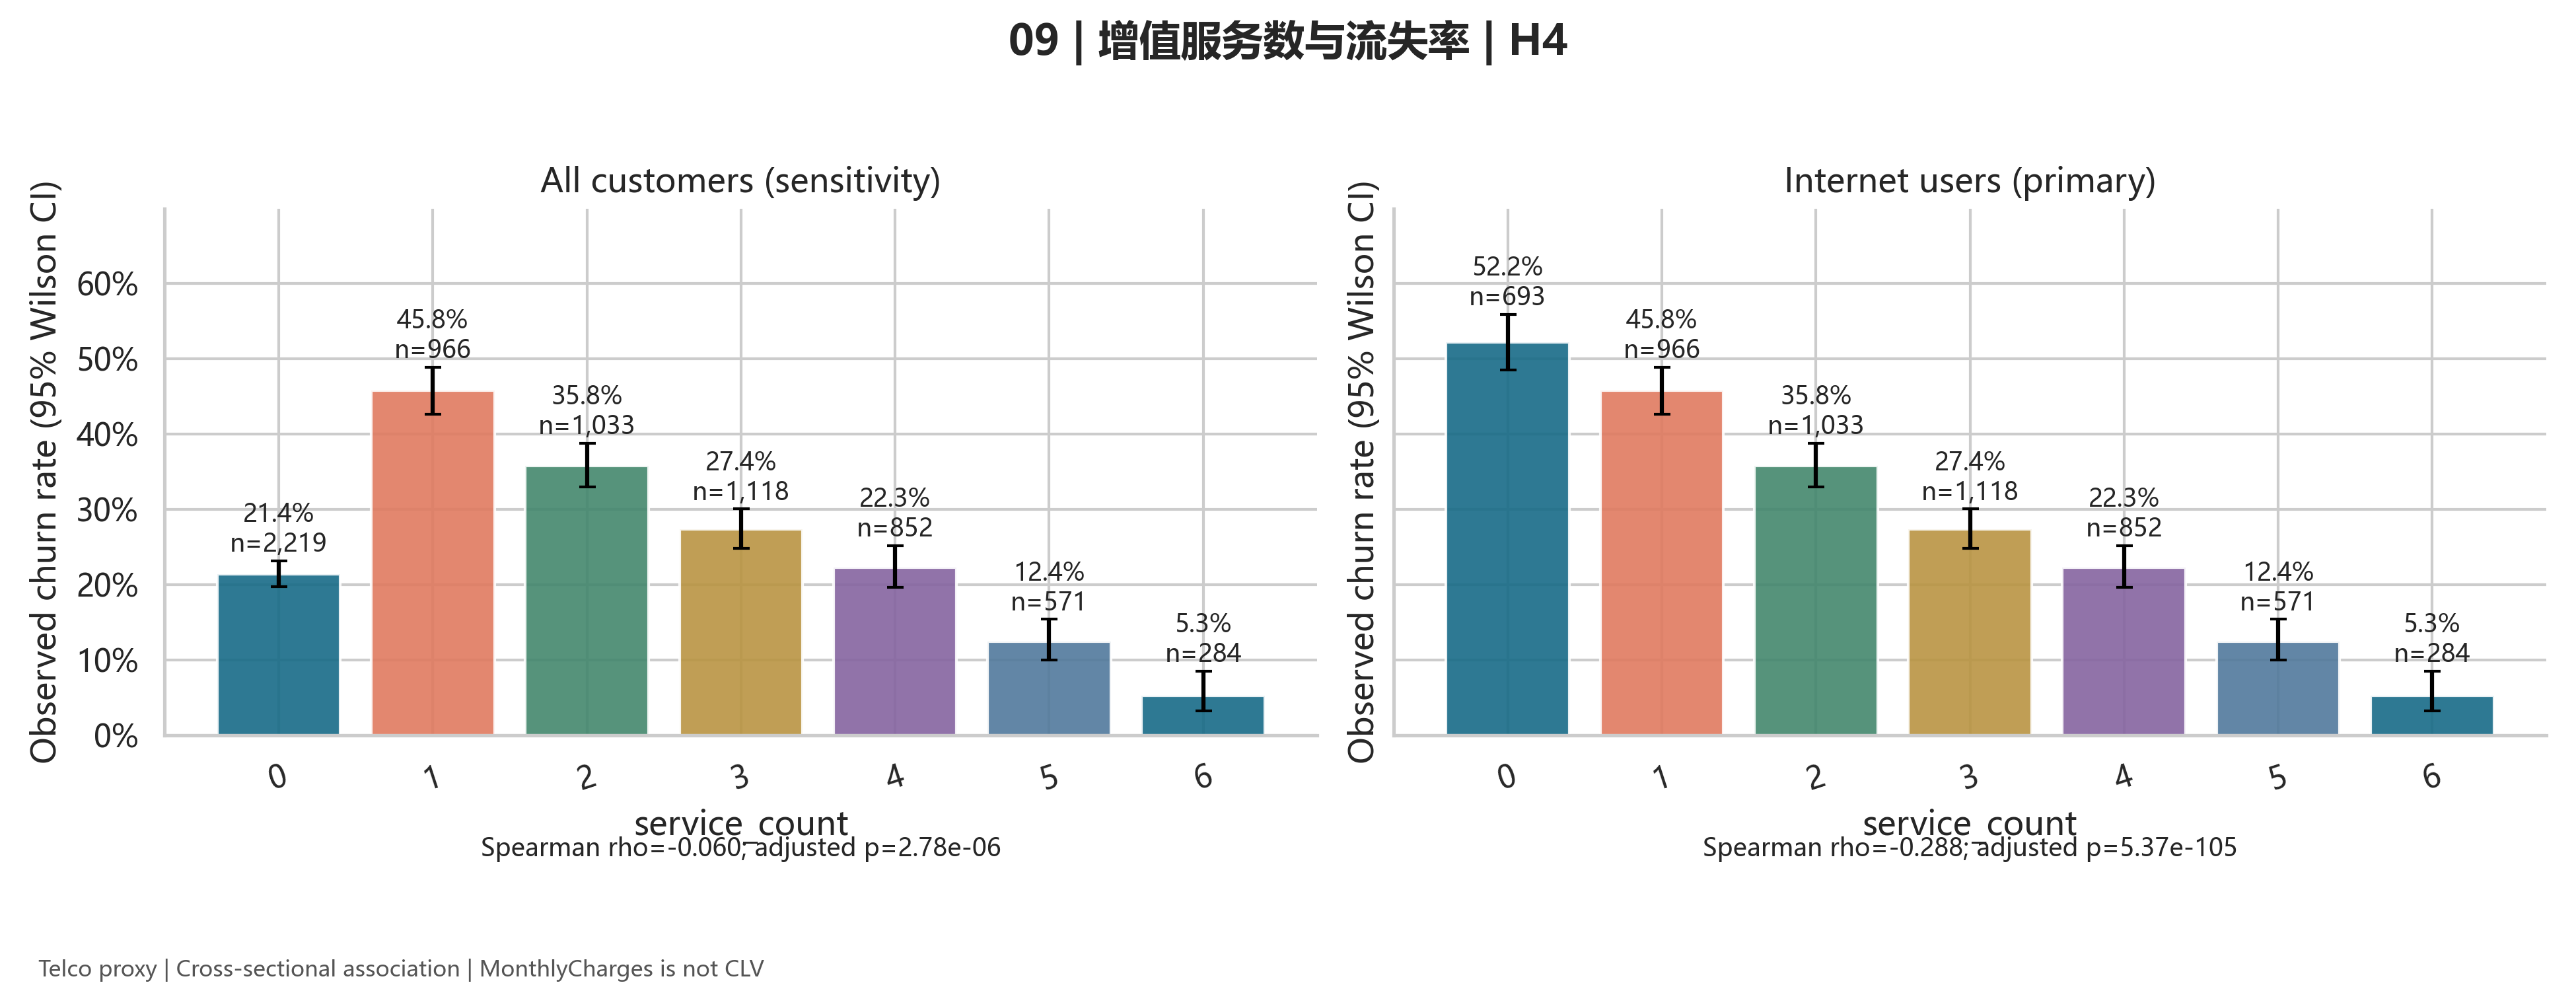

**结论：** 全体0服务组混合无互联网客户；互联网客户内少服务与较高流失相关。

**下一步：** W3保留无互联网状态；W4再将服务计数正式工程化。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_service_count_internet.csv`

In [11]:
chart = chart_index.loc[chart_index.chart_id.eq('09')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图10：各增值服务与流失率（互联网客户）（H4）

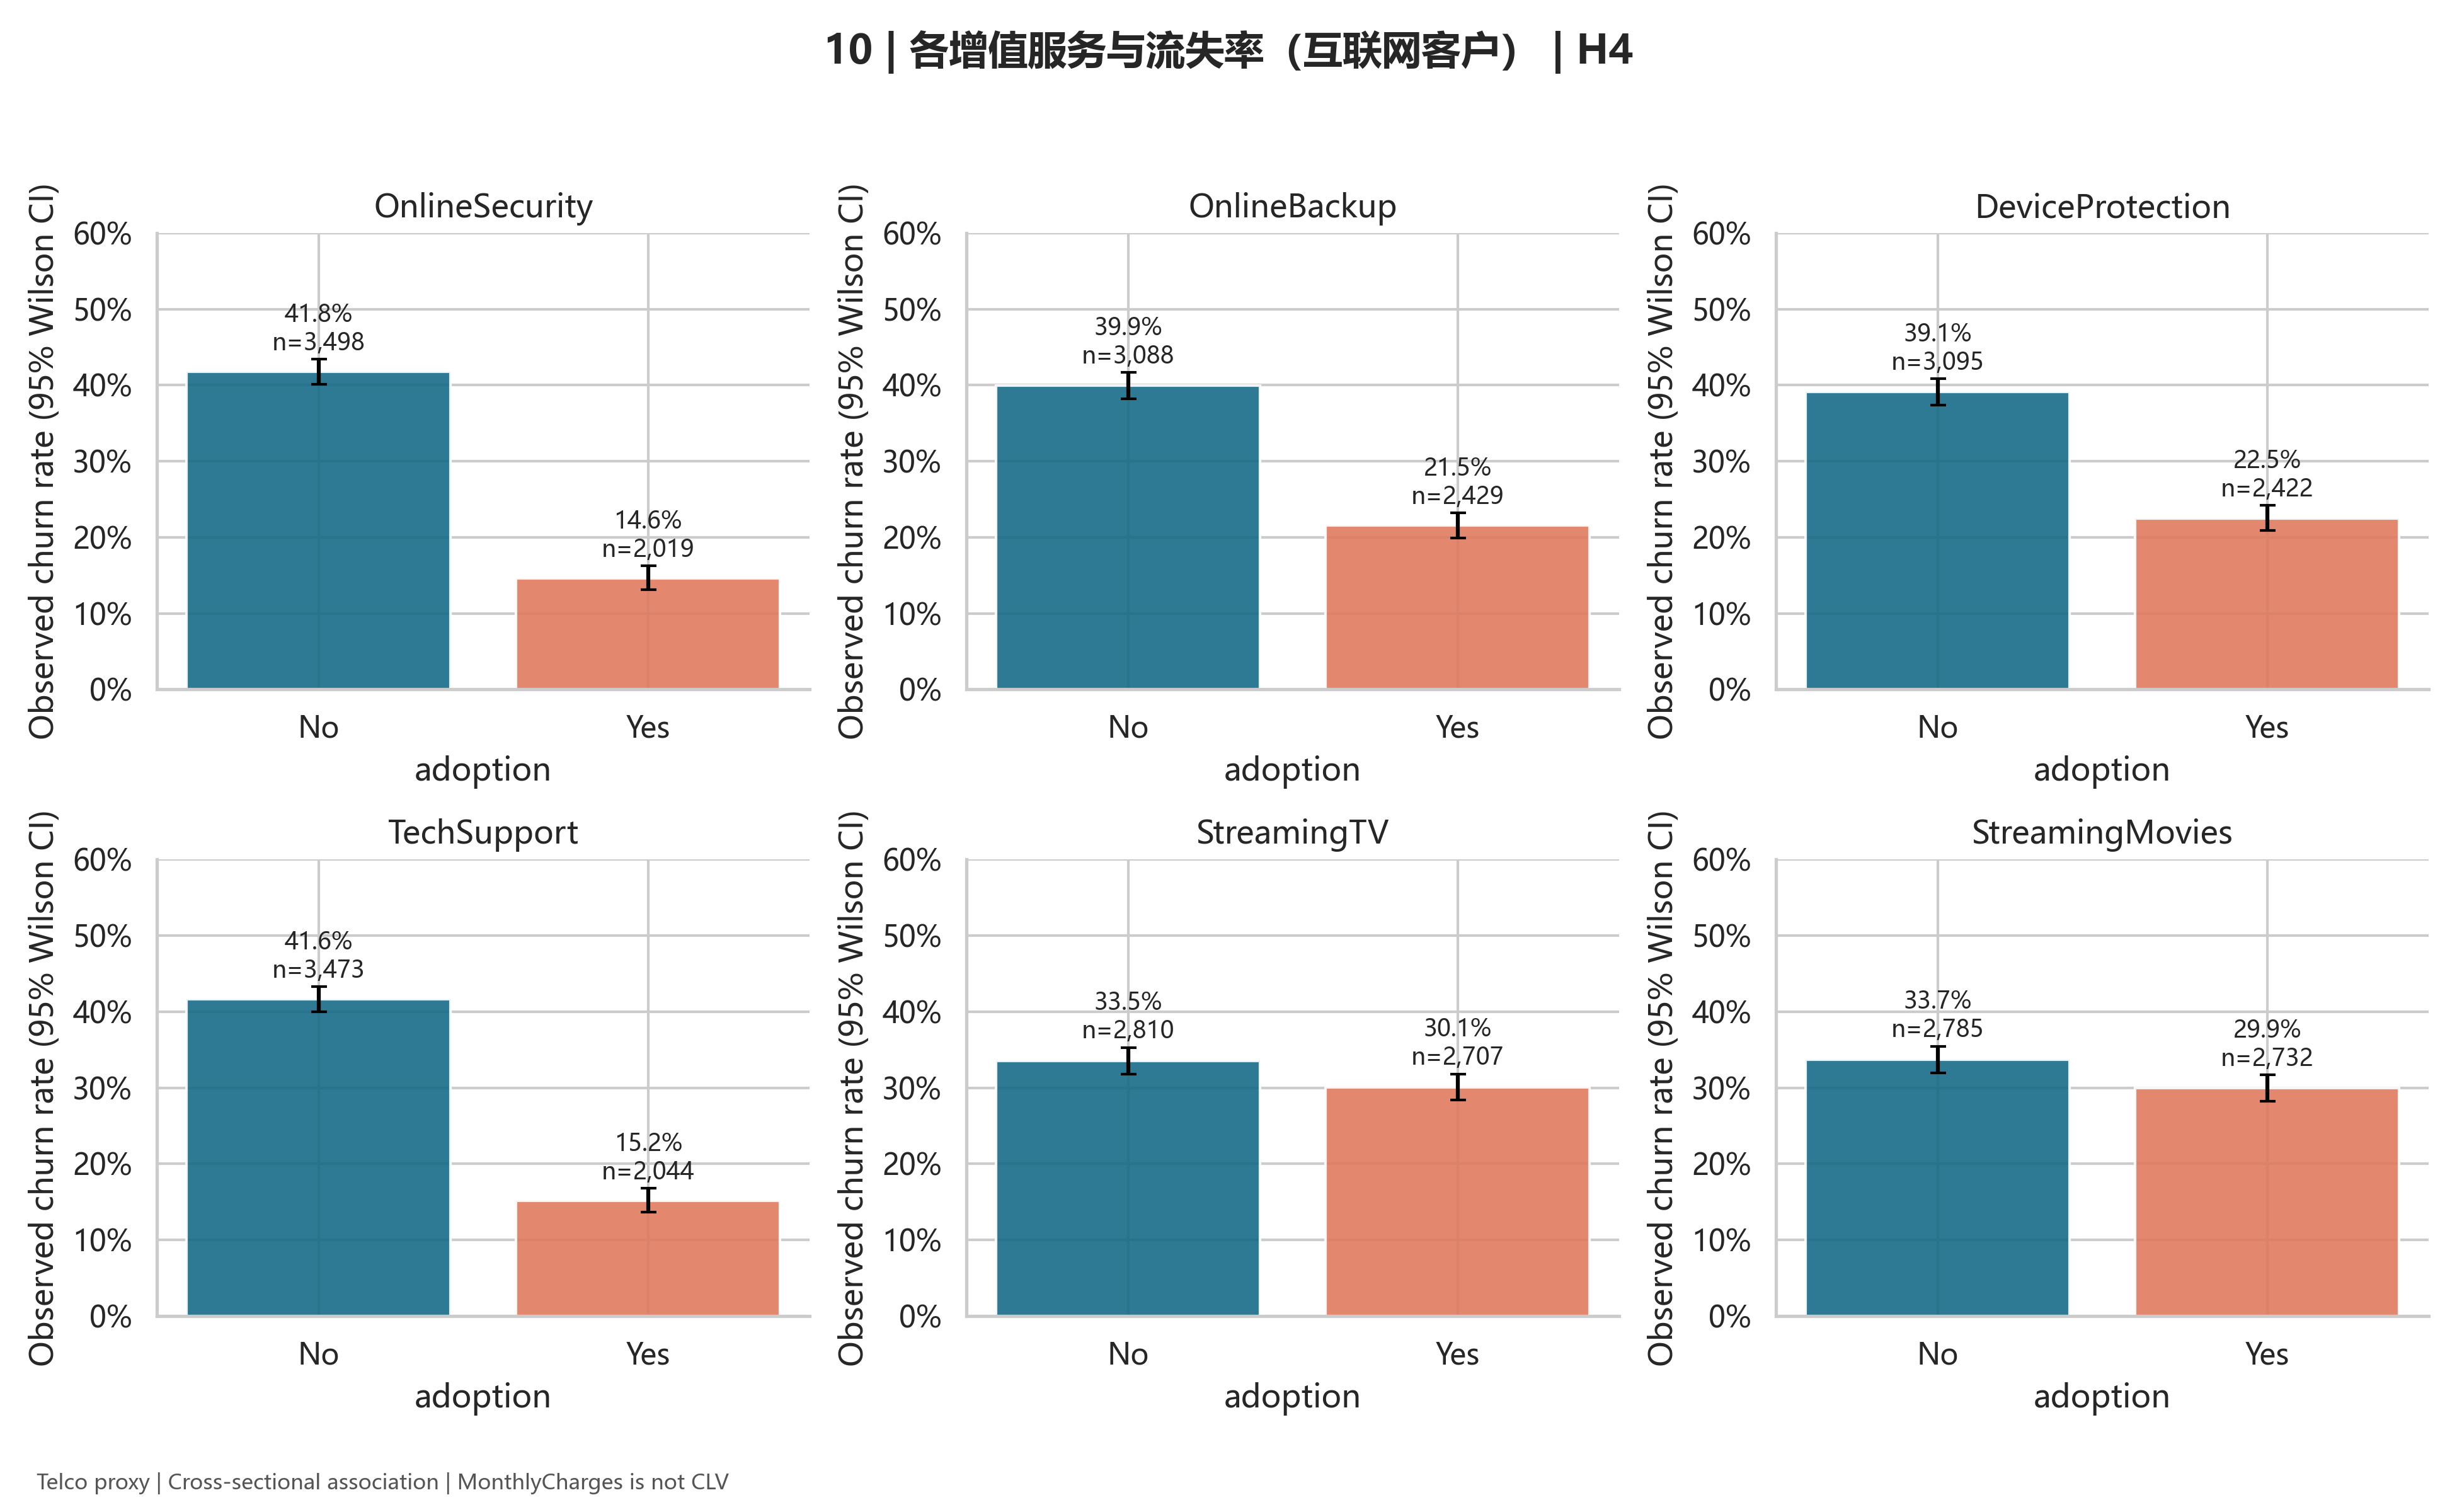

**结论：** 服务之间关联强度不同，安全与技术支持需重点进一步核查。

**下一步：** 六项比较使用Bonferroni校正，不能把采用关联解读为加购效果。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_individual_service_rates.csv`

In [12]:
chart = chart_index.loc[chart_index.chart_id.eq('10')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图11：月费四分位与流失率（H10）

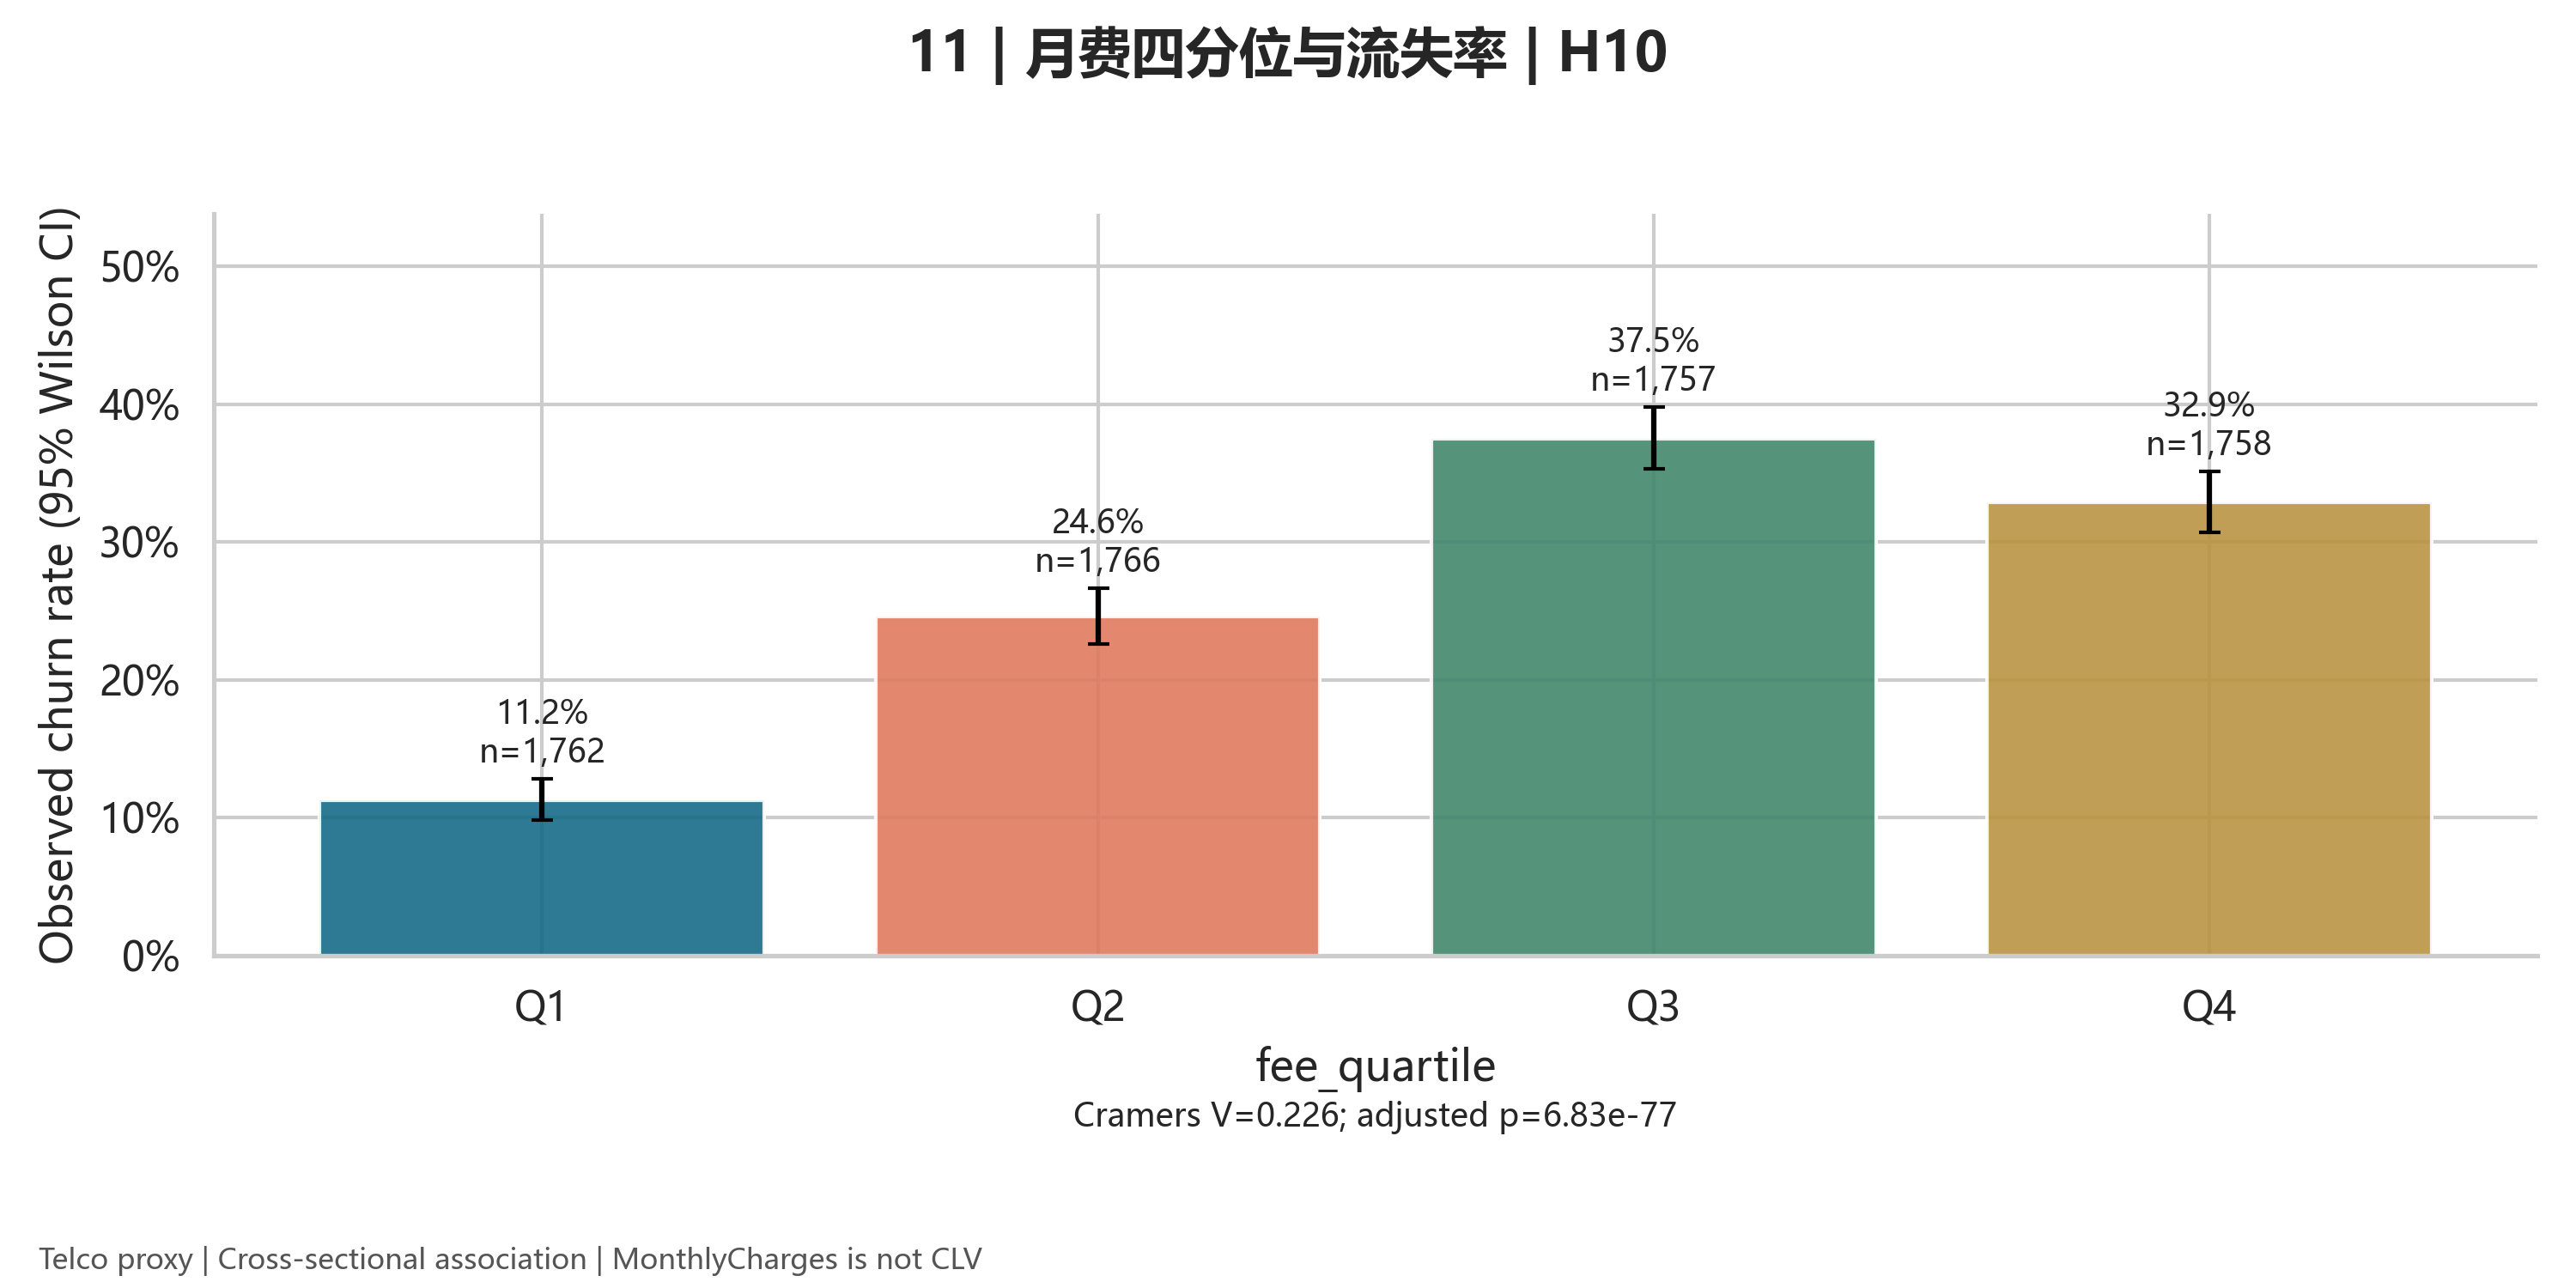

**结论：** 月费组间流失率有差异，具体走势见分位表，不能假设严格单调。

**下一步：** 价值优先级同时参考风险规则和费用，暂不计算CLV。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_fee_quartile_rates.csv`

In [13]:
chart = chart_index.loc[chart_index.chart_id.eq('11')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图12：月费与服务数（互联网客户）（H5）

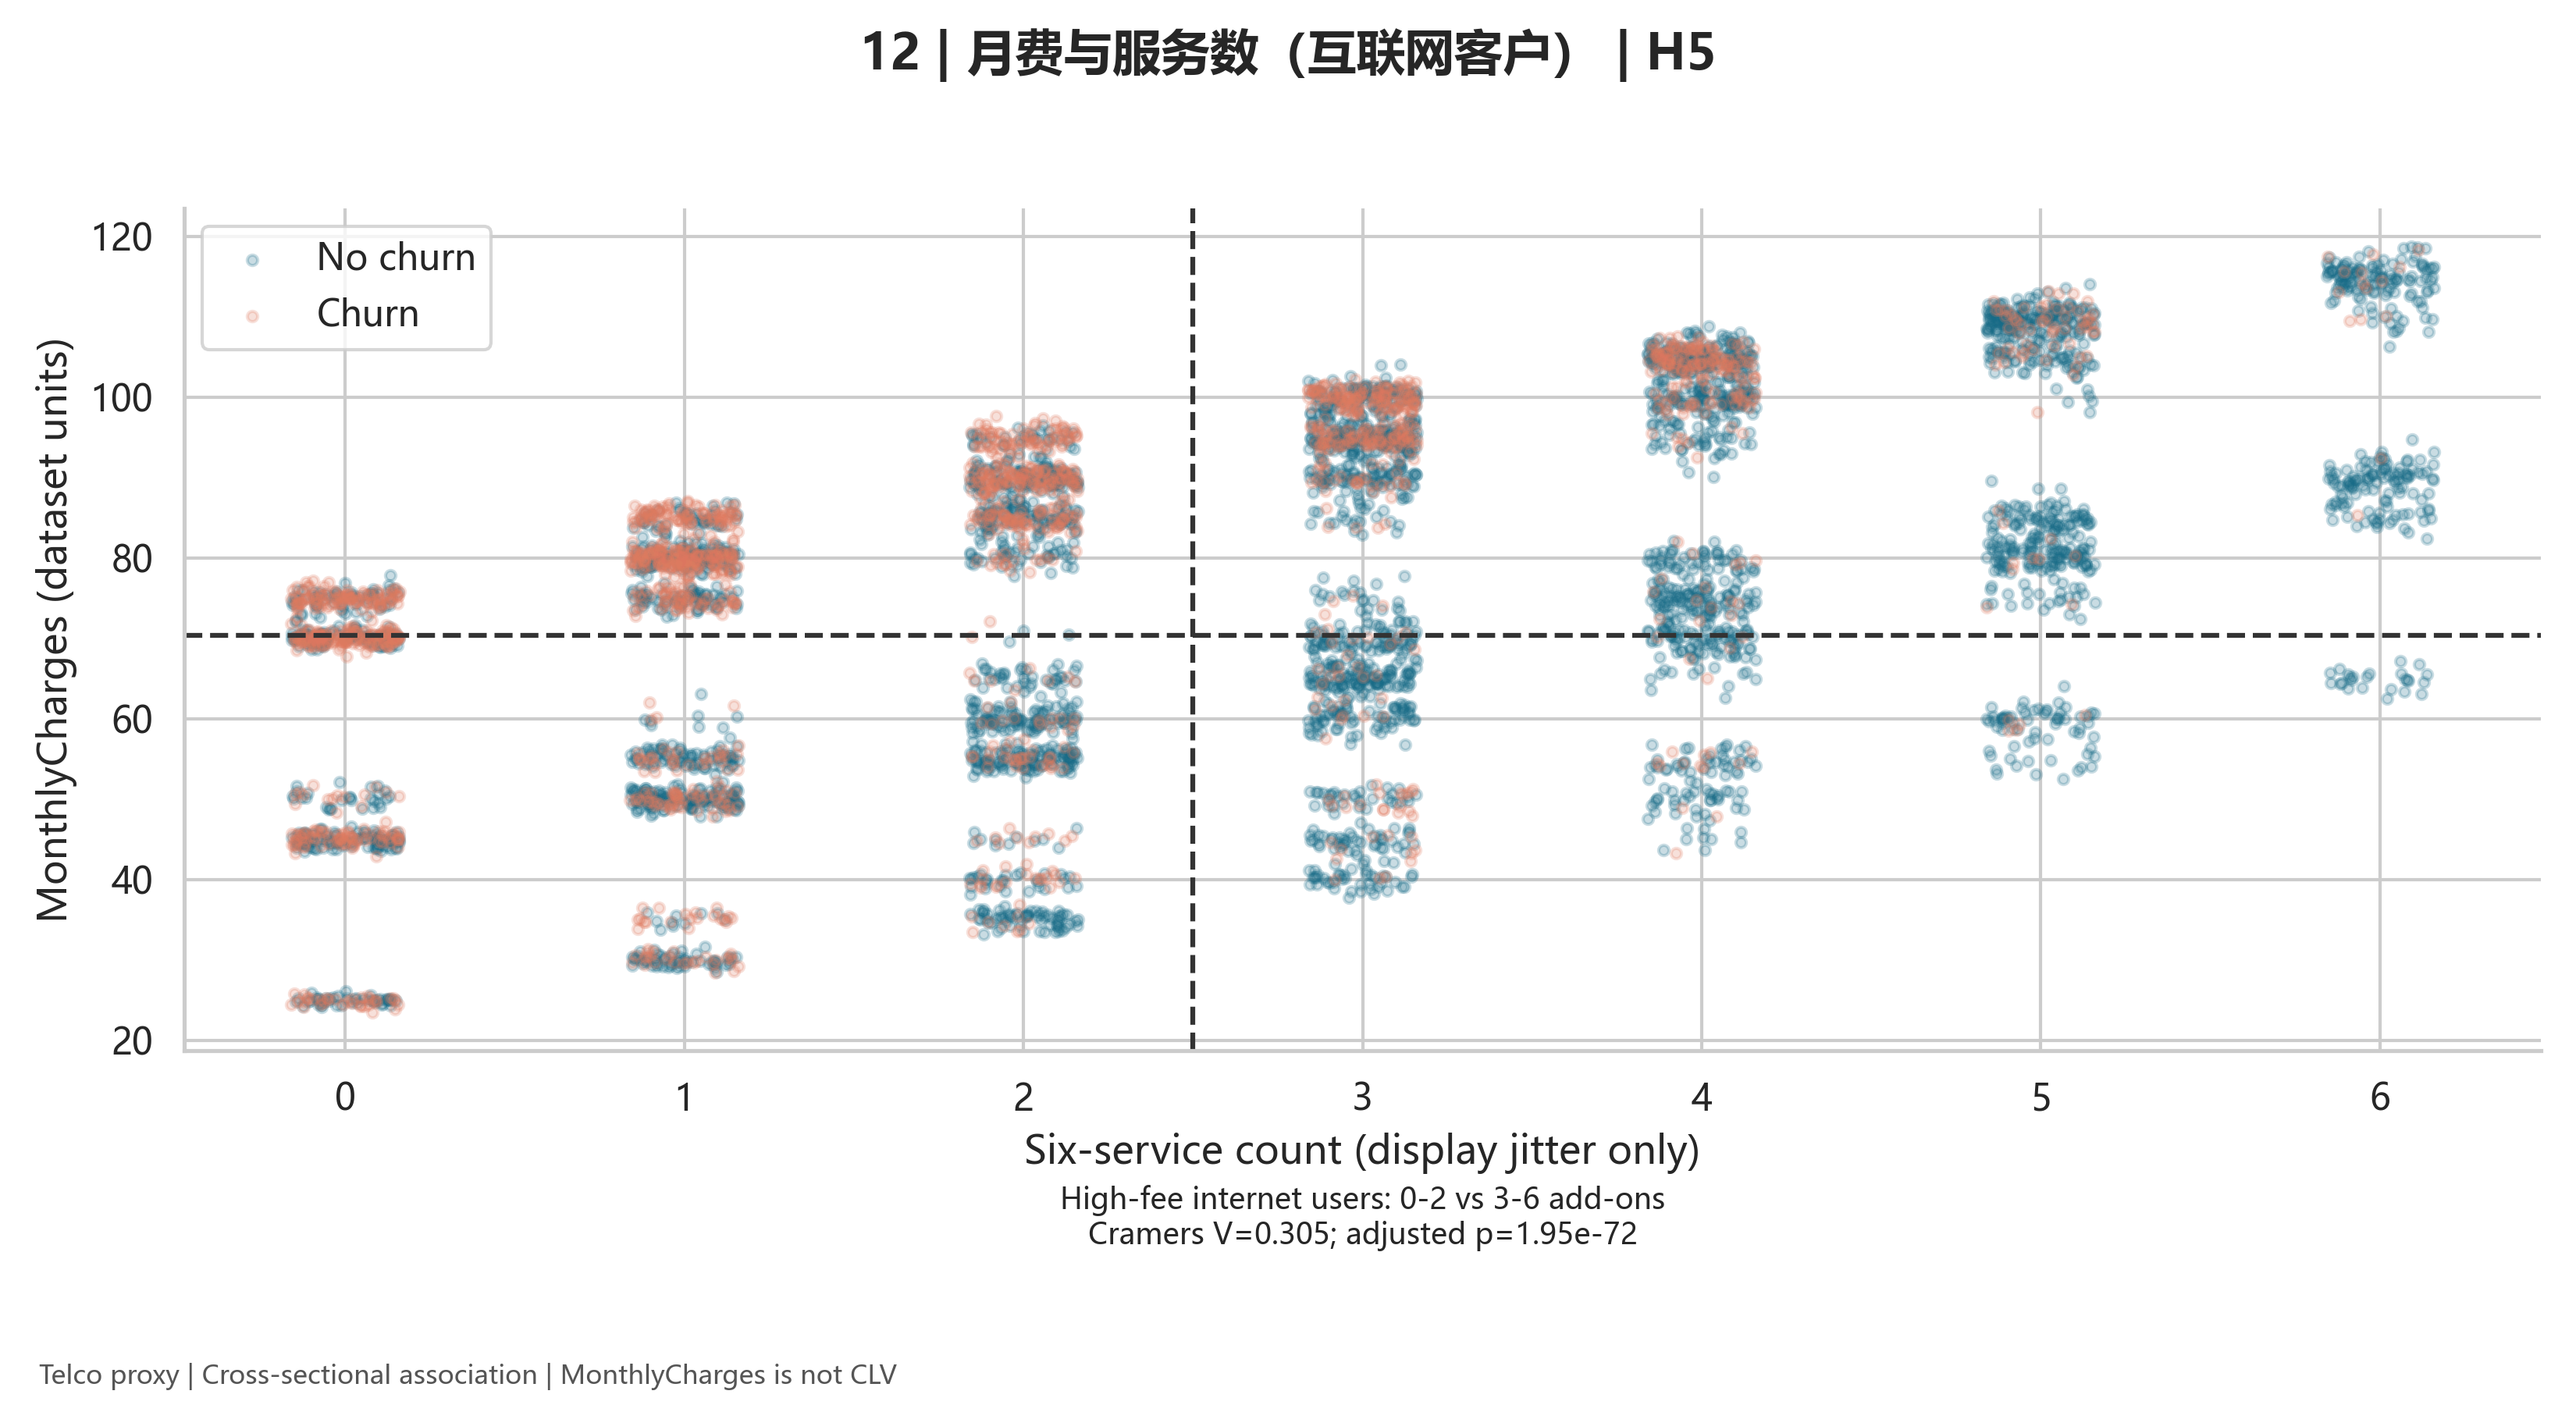

**结论：** 高月费0–2服务组流失53.30%，3–6服务组23.47%。

**下一步：** 核查套餐与服务适配；价格感知和实际使用深度缺字段，尚不可验证。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_fee_service_rates.csv`

In [14]:
chart = chart_index.loc[chart_index.chart_id.eq('12')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图13：支付方式与流失率（H6）

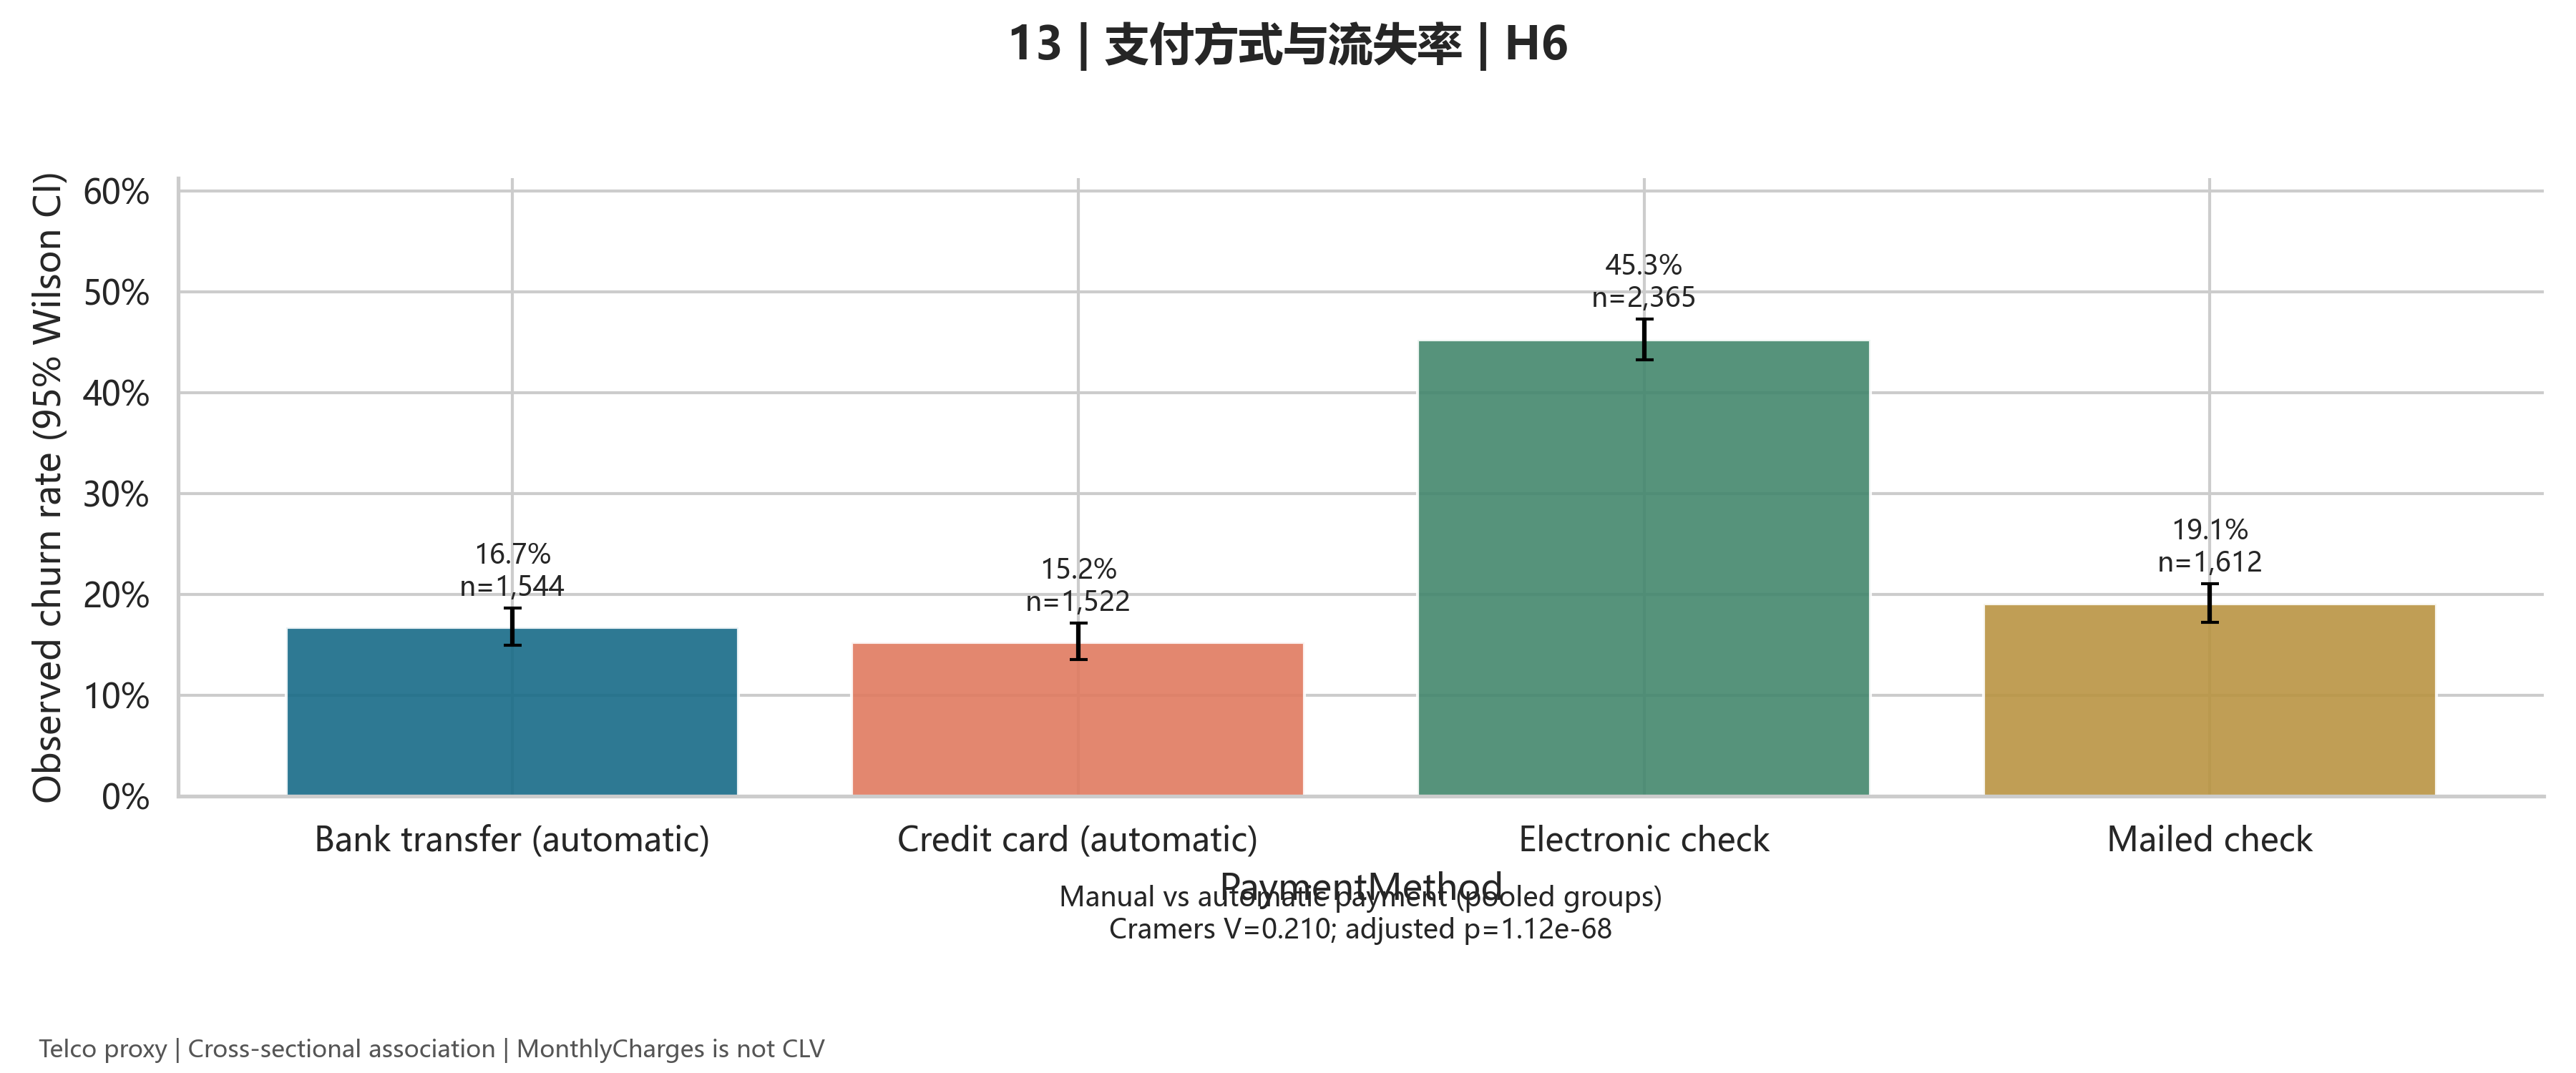

**结论：** Electronic check组流失率较高，手动支付组内部也有差异。

**下一步：** 支付方式不等于支付失败或自动续费；先核查合同构成。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_payment_rates.csv`

In [15]:
chart = chart_index.loc[chart_index.chart_id.eq('13')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

## D4：人口细分、交叉分析与矩阵雏形

### 图14：人口统计细分与流失率（H9）

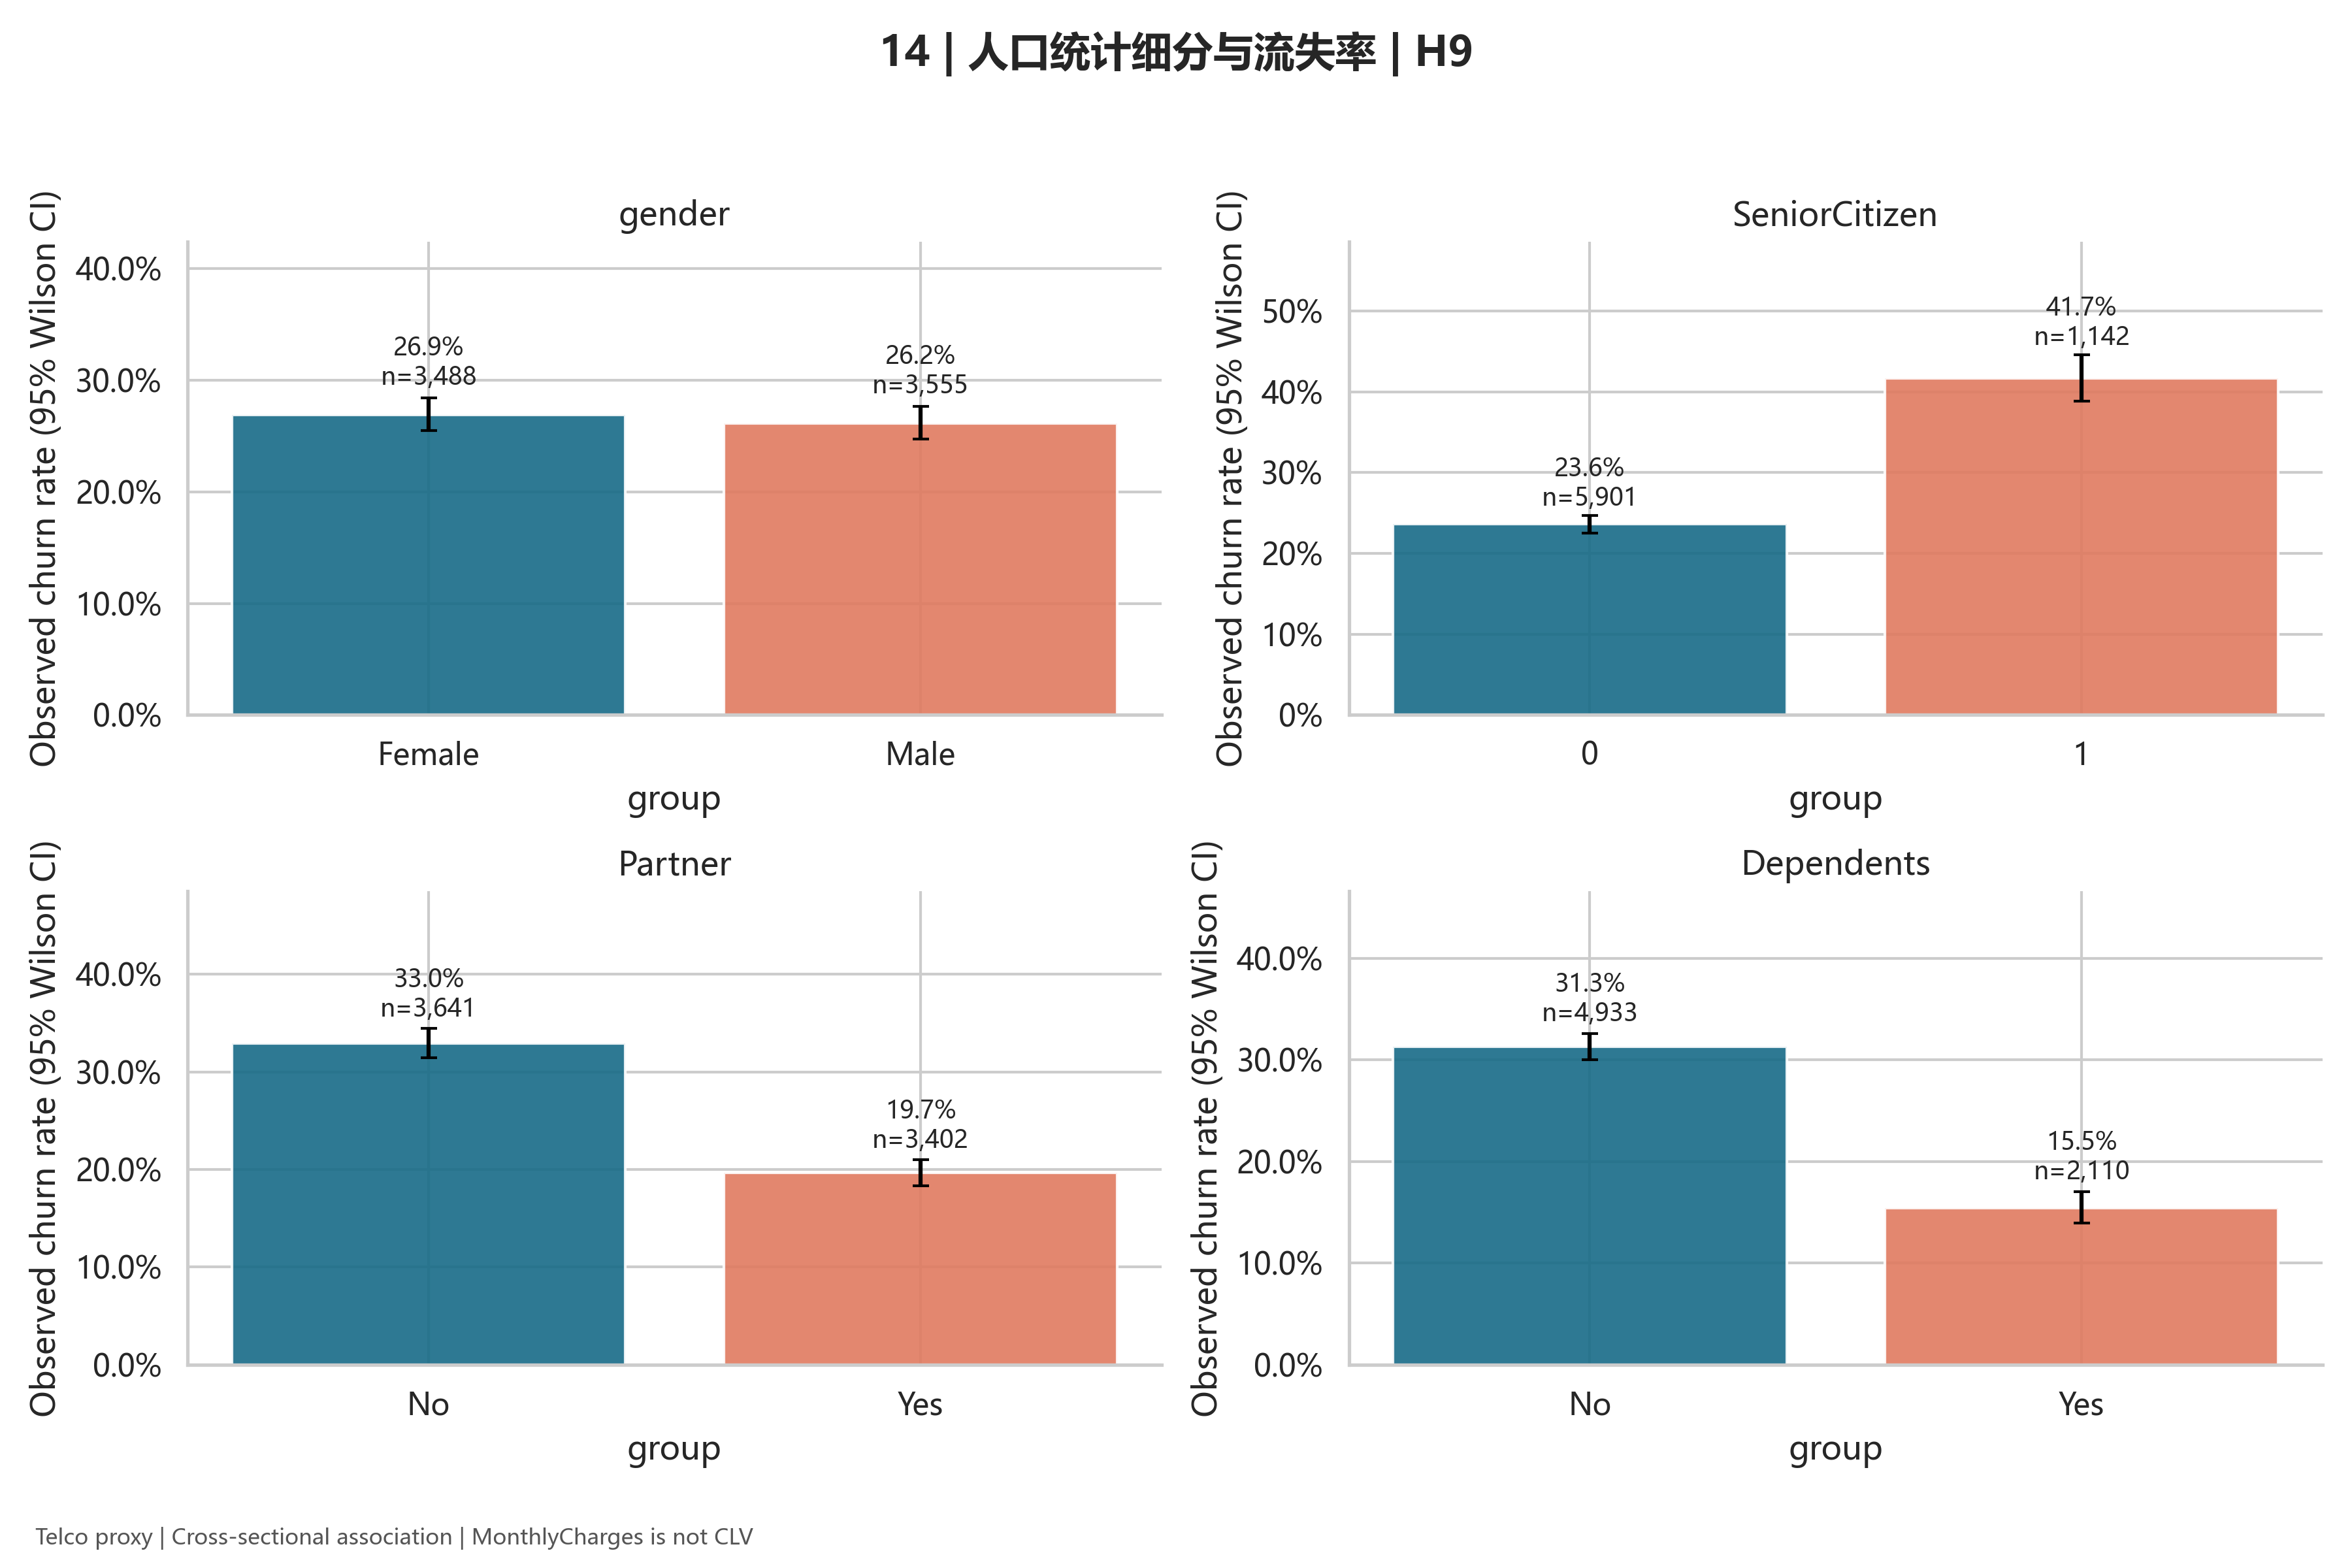

**结论：** 并非所有人口字段都存在显著差异；性别与其他细分分别检验。

**下一步：** 仅用于公平性与细分稳定性核查，不替代缺失的地区或行业字段。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_demographic_rates.csv`

In [16]:
chart = chart_index.loc[chart_index.chart_id.eq('14')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图15：合同×年限交叉流失率（H1,H2）

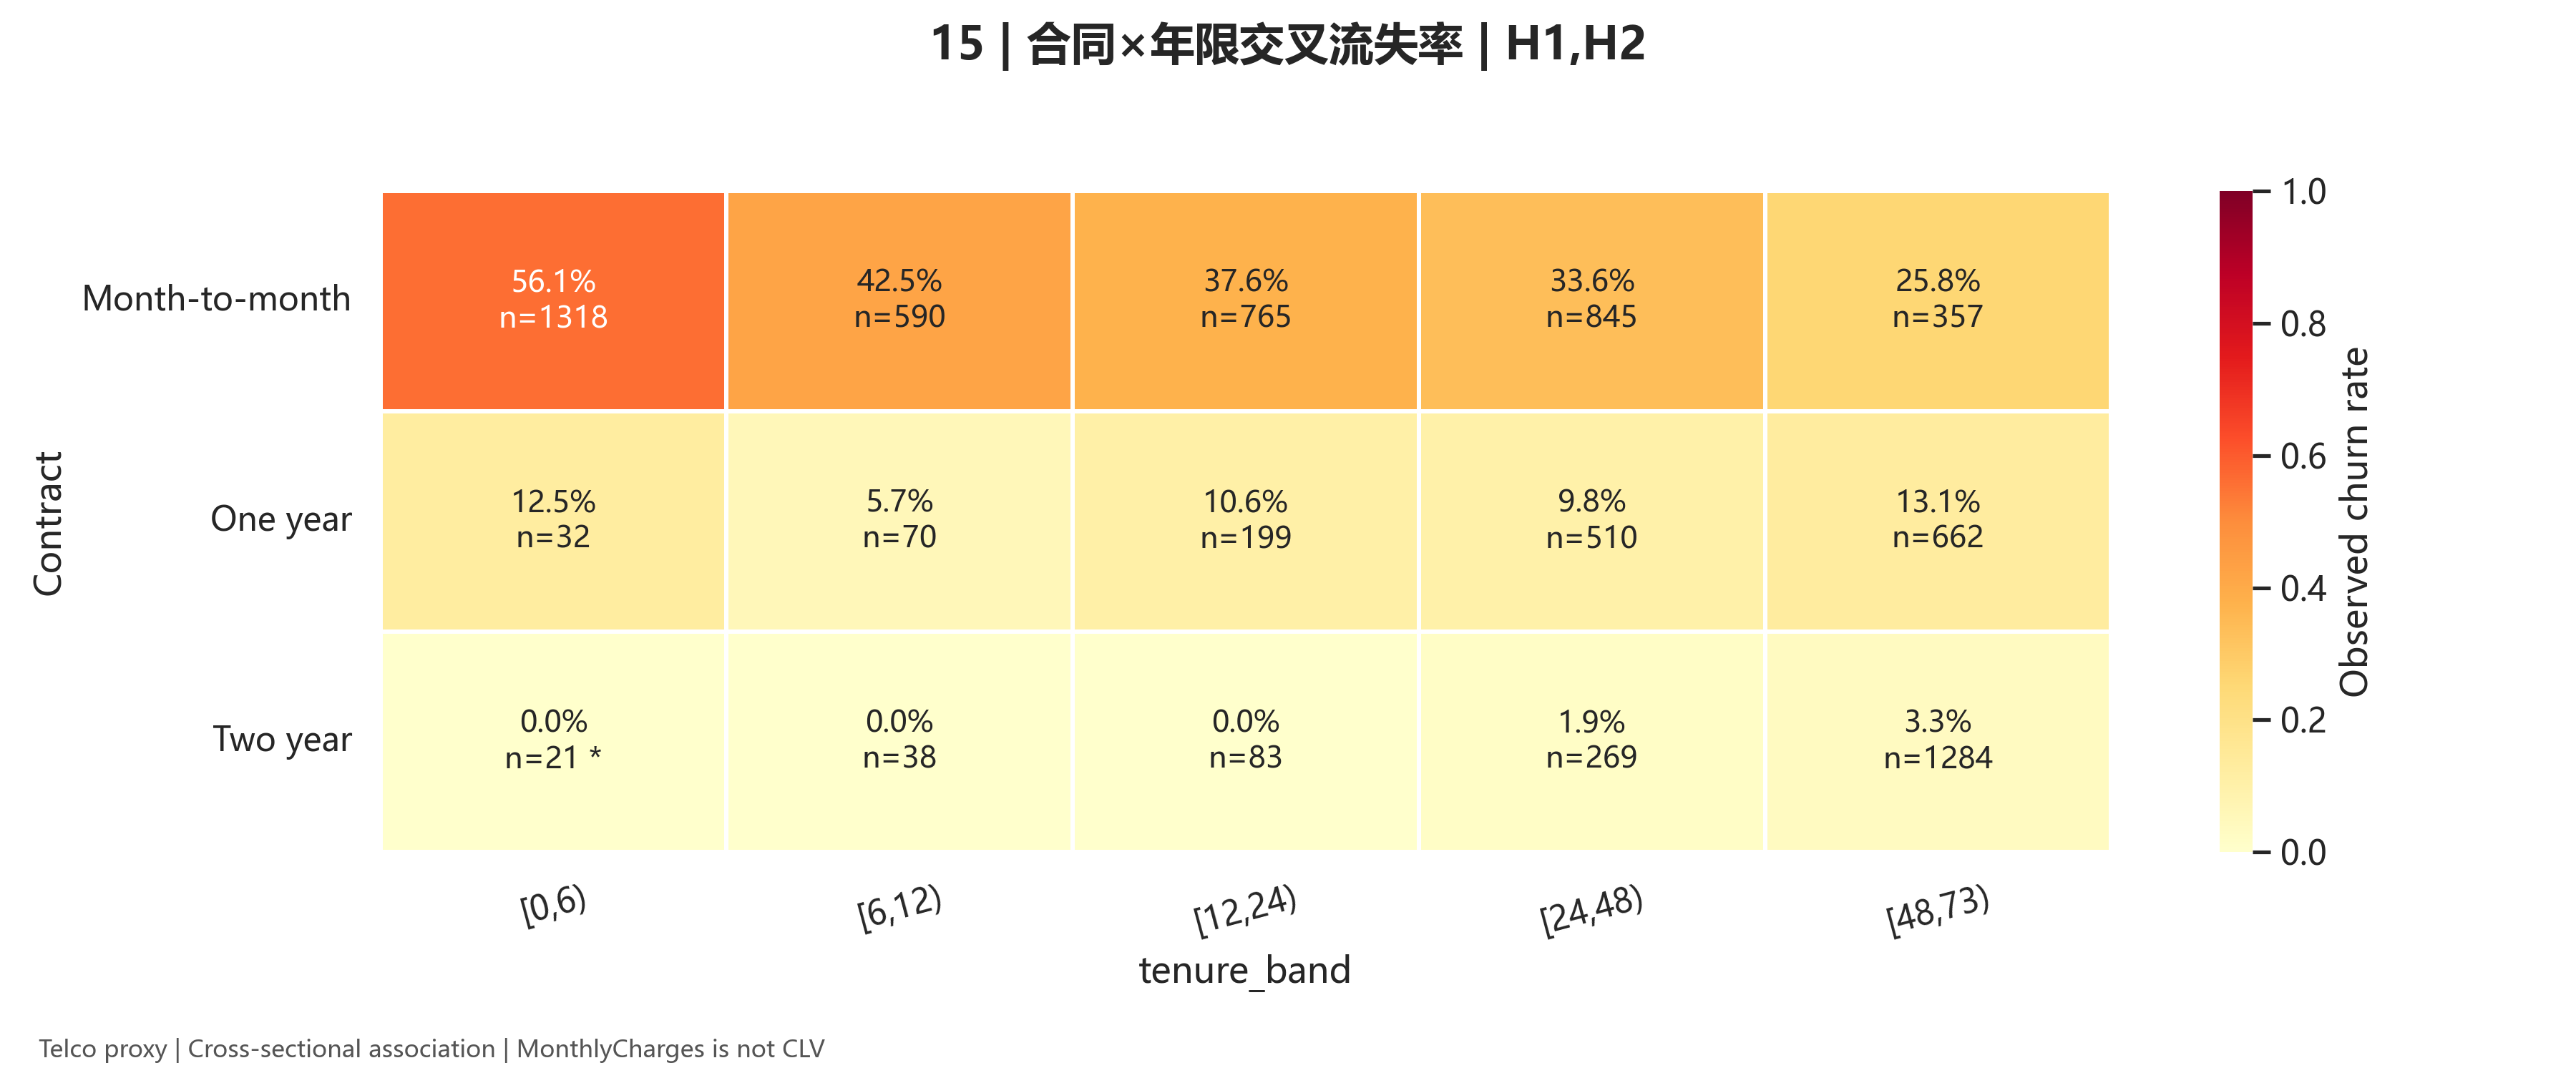

**结论：** 月付与短年限组合呈较高观察流失；小样本格标*，不据此作稳定排序。

**下一步：** W4记录交互候选；未做正式交互显著性检验。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_contract_tenure_rates.csv`

In [17]:
chart = chart_index.loc[chart_index.chart_id.eq('15')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图16：数值变量Spearman相关矩阵（H2,H4,H10）

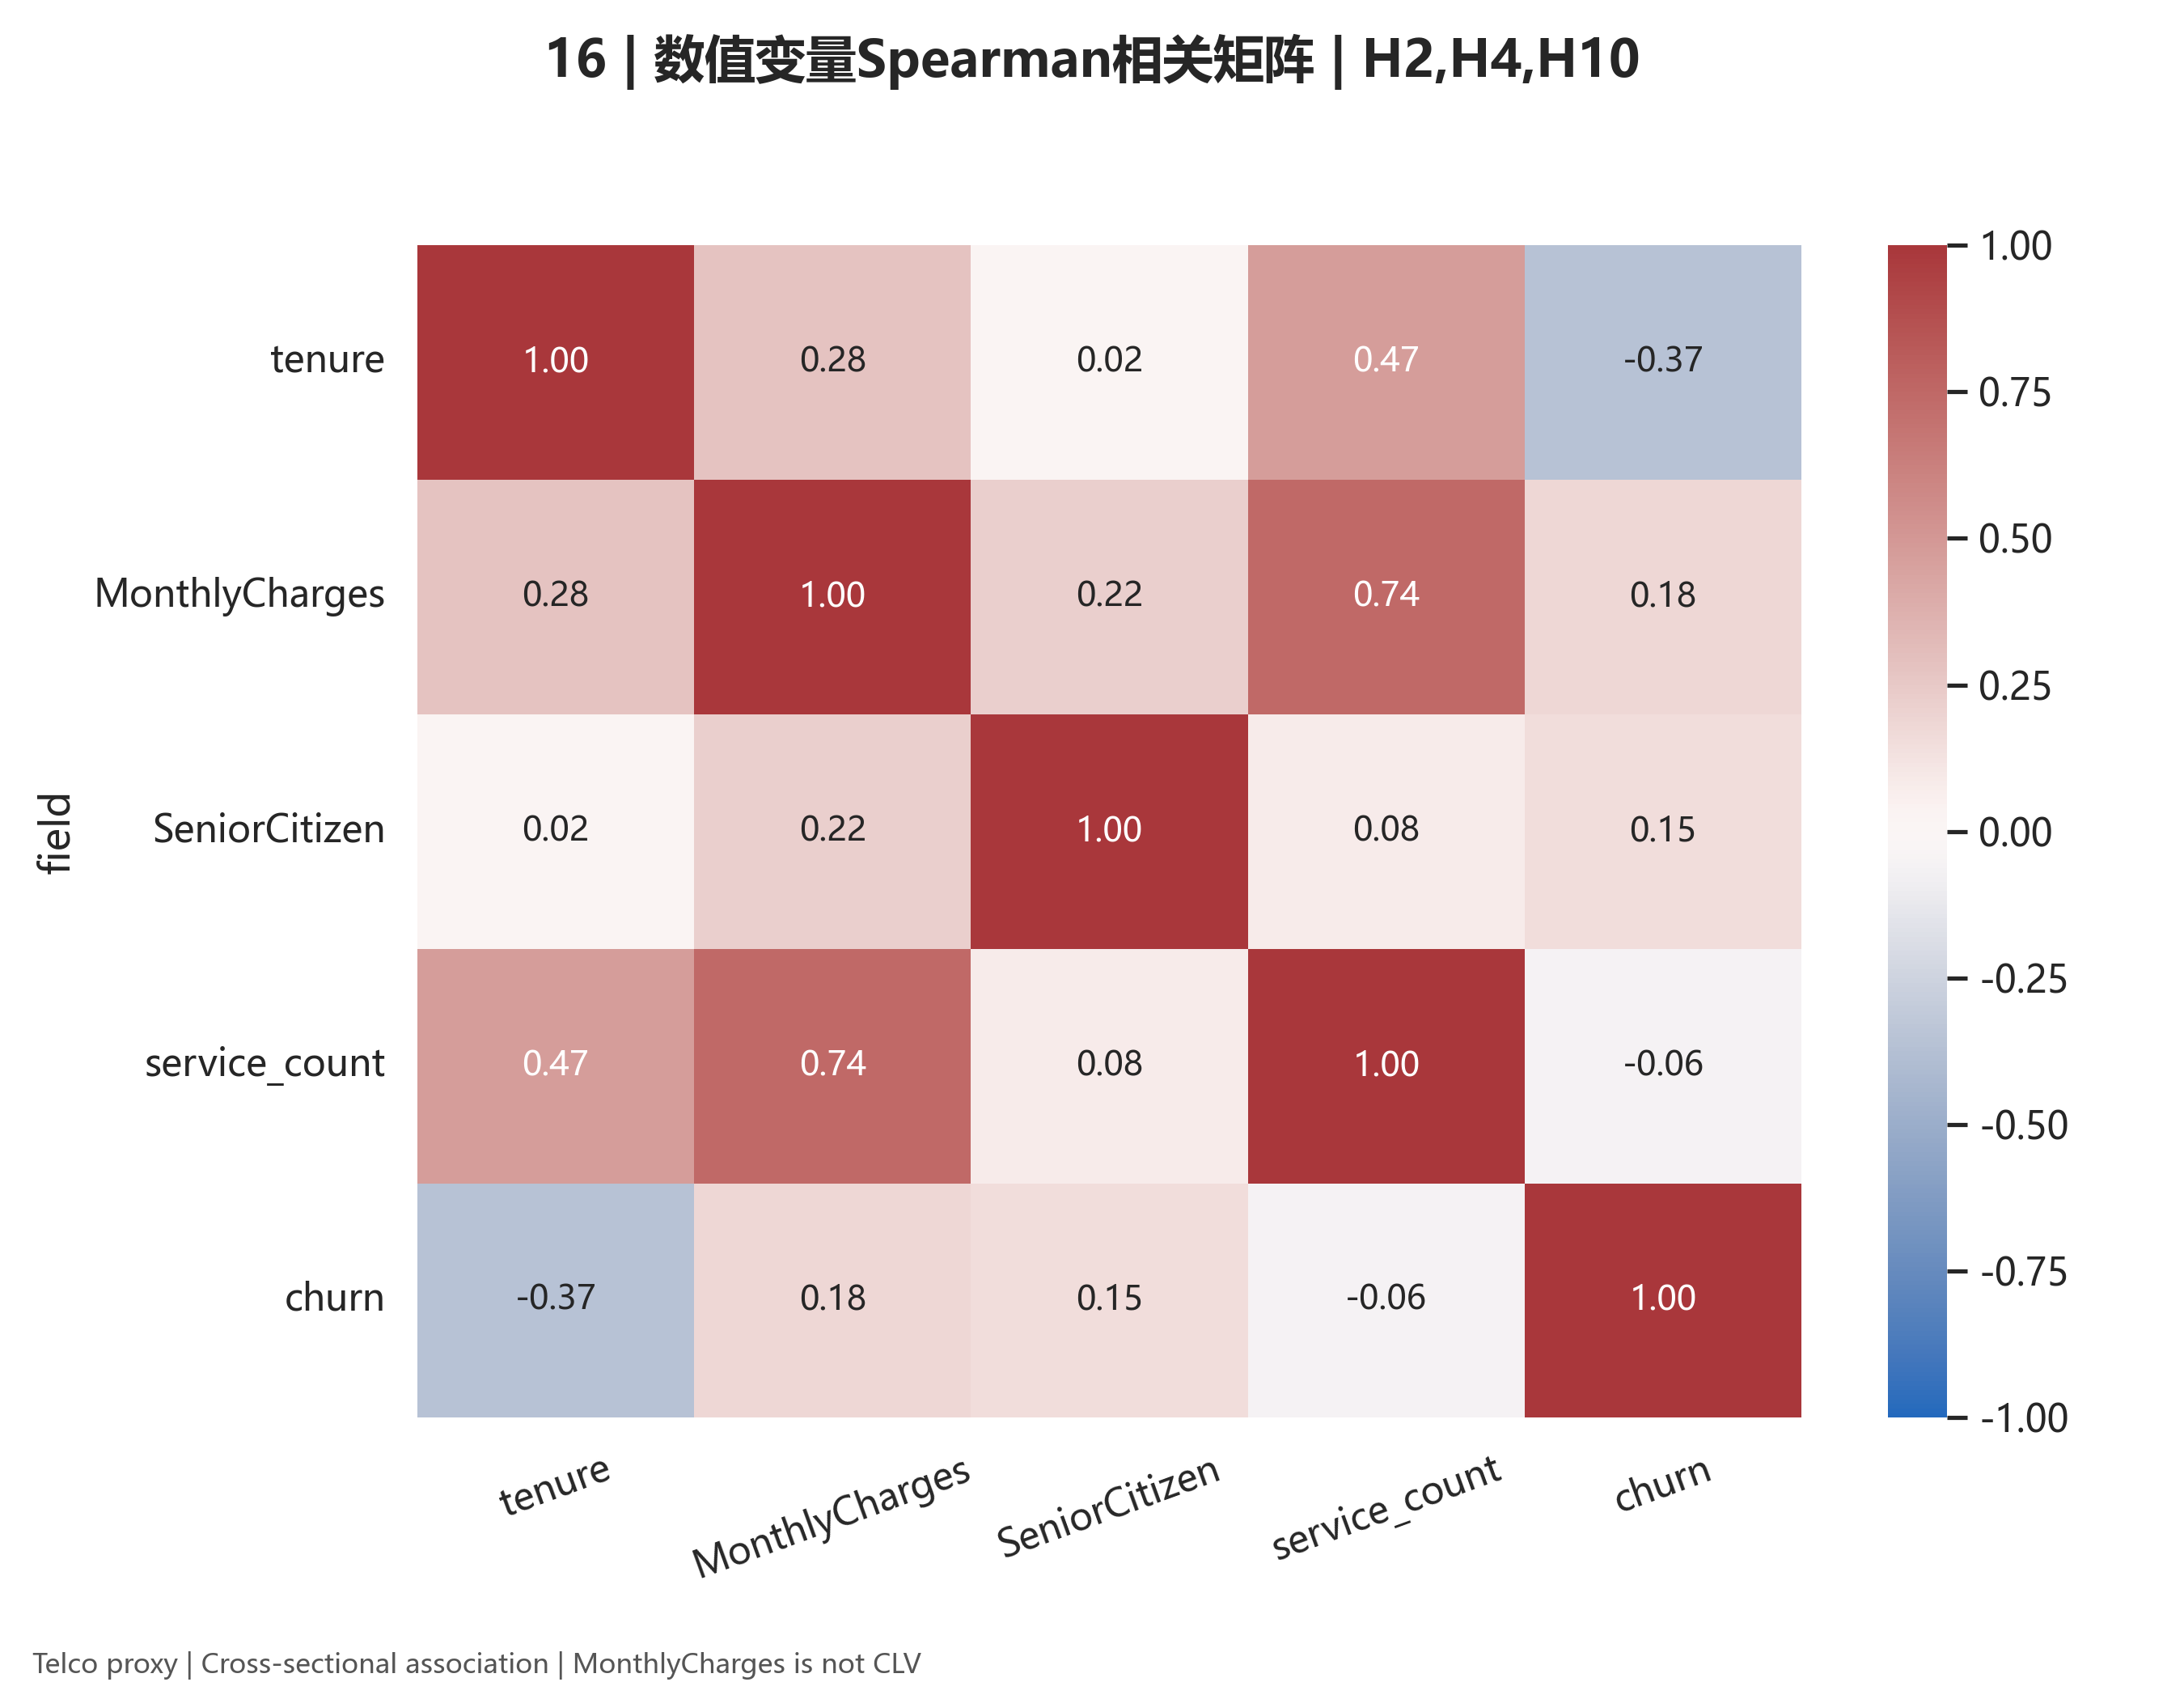

**结论：** 矩阵含Churn仅作标签关联说明；服务数与费用也存在关联。

**下一步：** W4排除Churn及其派生字段；本图不构成完整共线性诊断。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_spearman_matrix.csv`

In [18]:
chart = chart_index.loc[chart_index.chart_id.eq('16')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图17：风险规则×月费价值代理矩阵（H10）

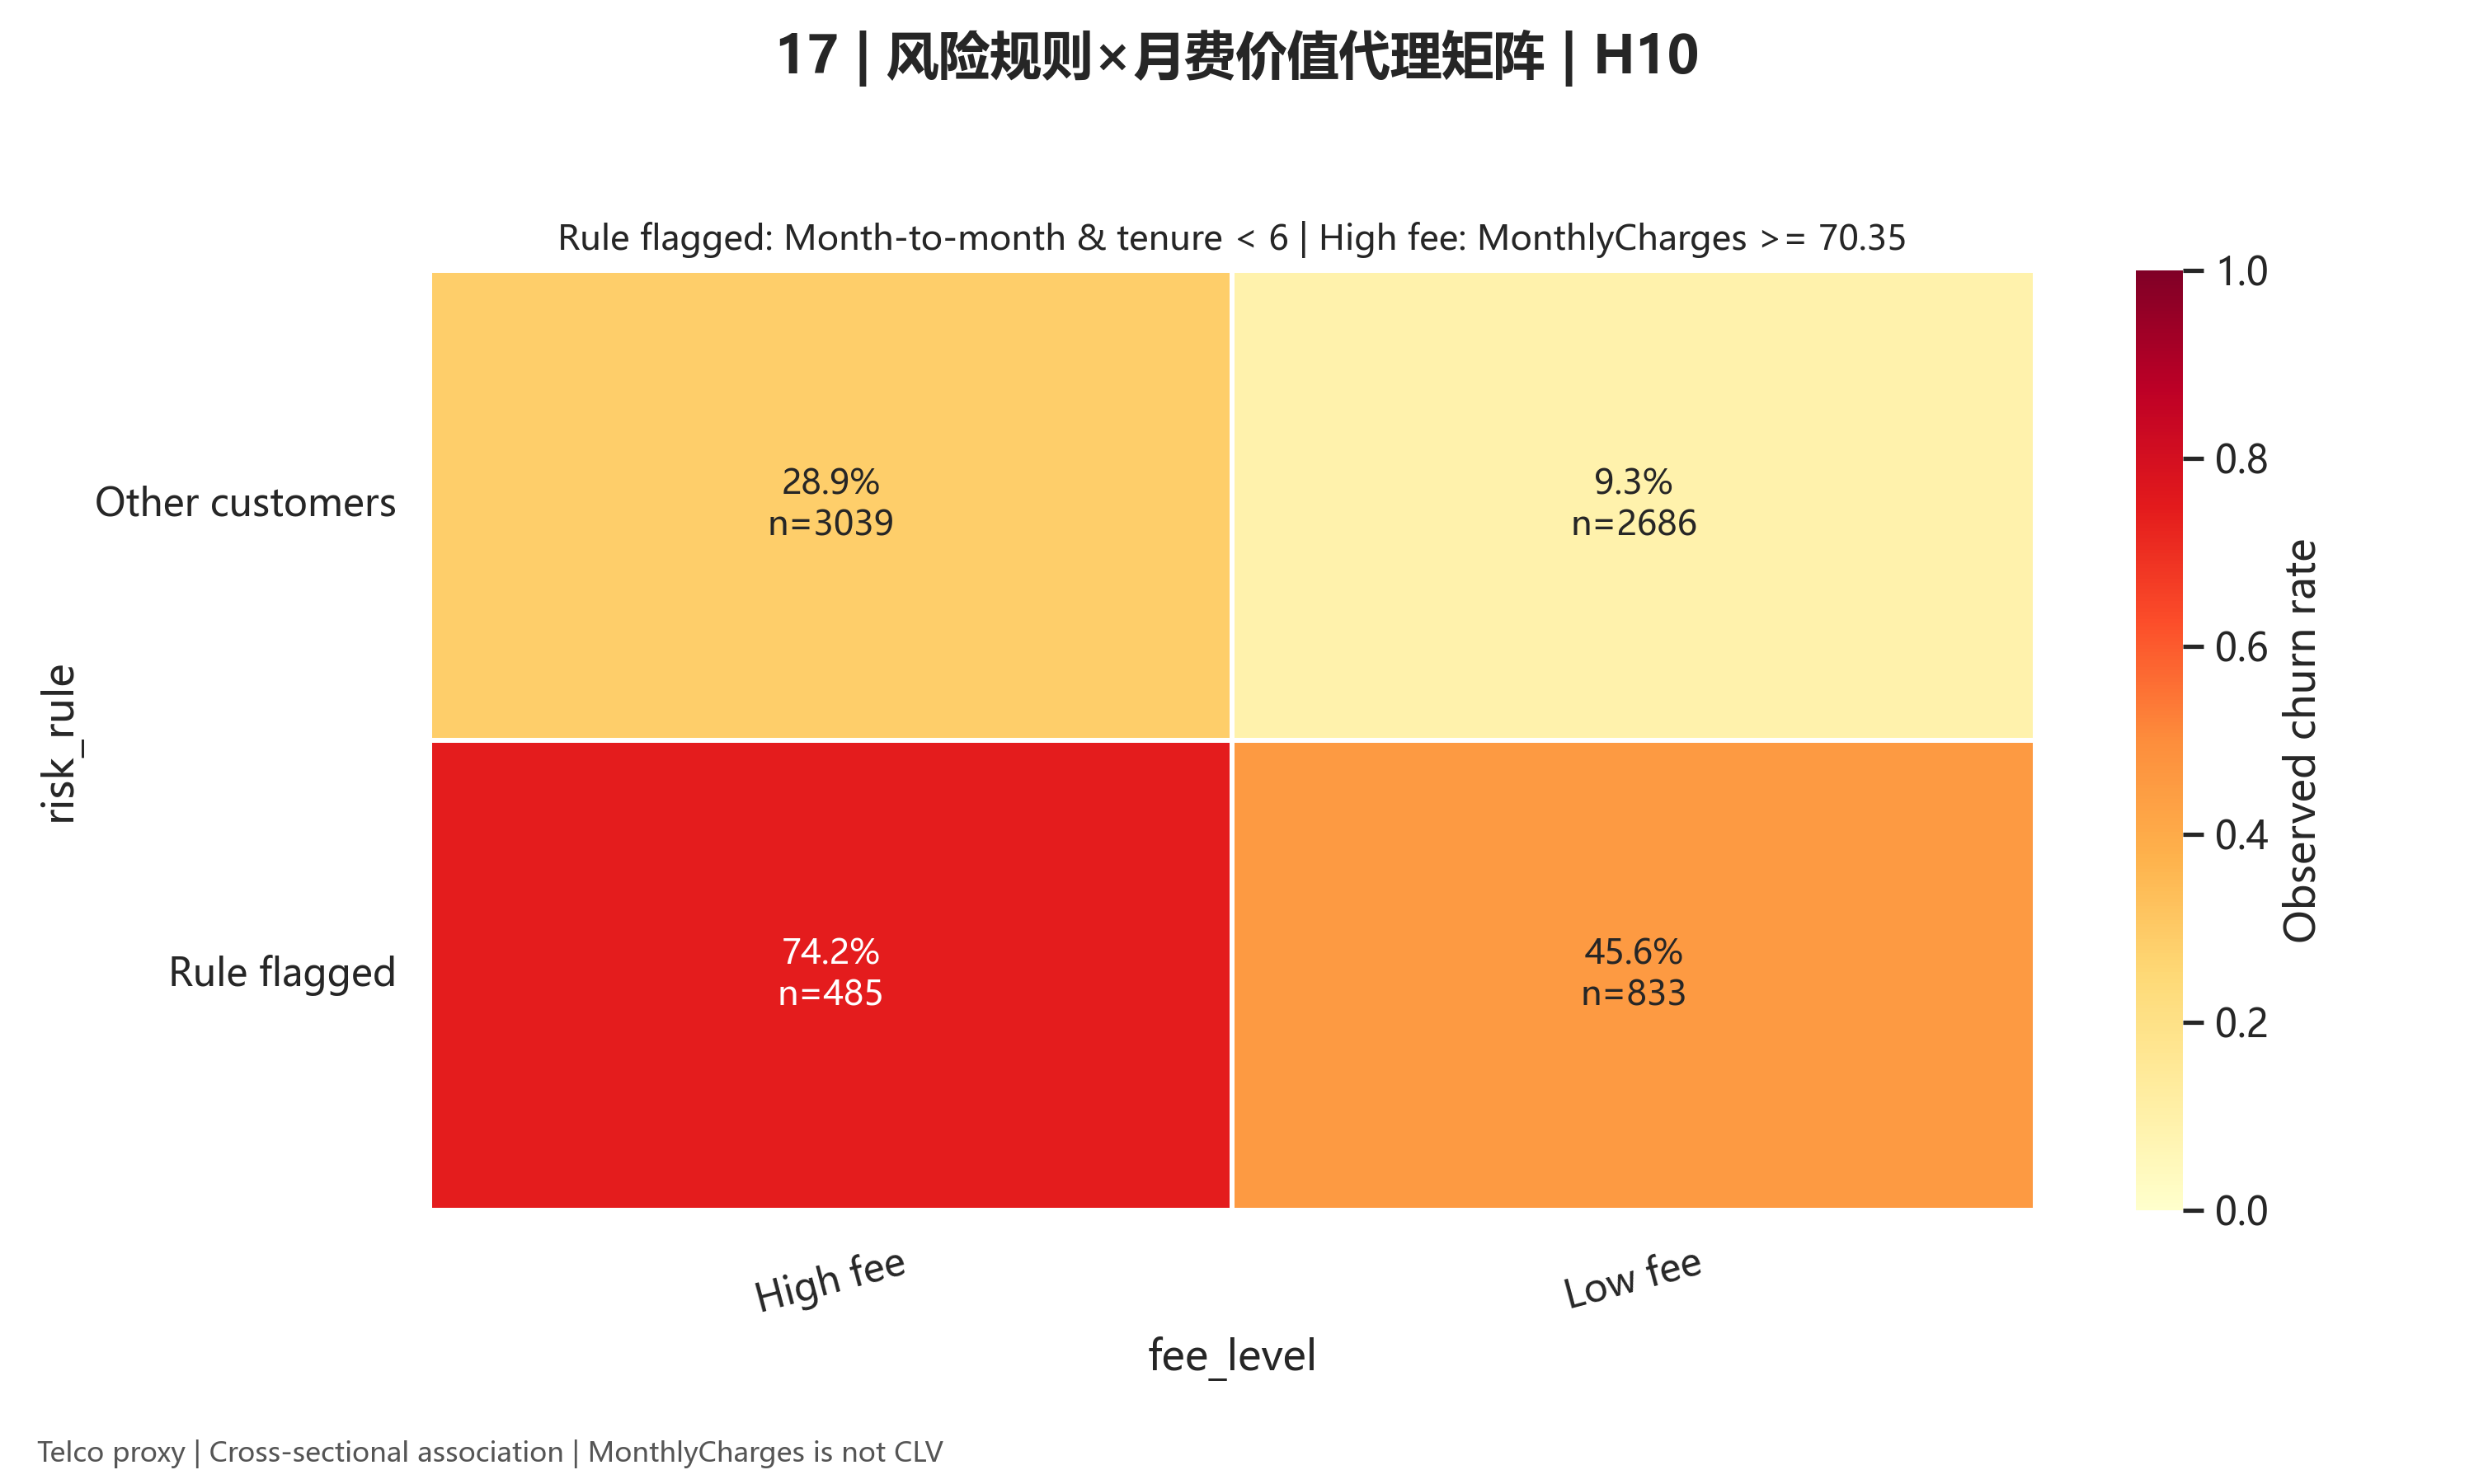

**结论：** 风险规则为月付且tenure<6，高价值为月费≥全体中位数；格内为已观察流失率。

**下一步：** 仅展示分层雏形；W7完成验证后的风险评分才可支持后续排序。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_risk_value_prototype.csv`

In [19]:
chart = chart_index.loc[chart_index.chart_id.eq('17')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图18：互联网类型内的服务数对比（H4）

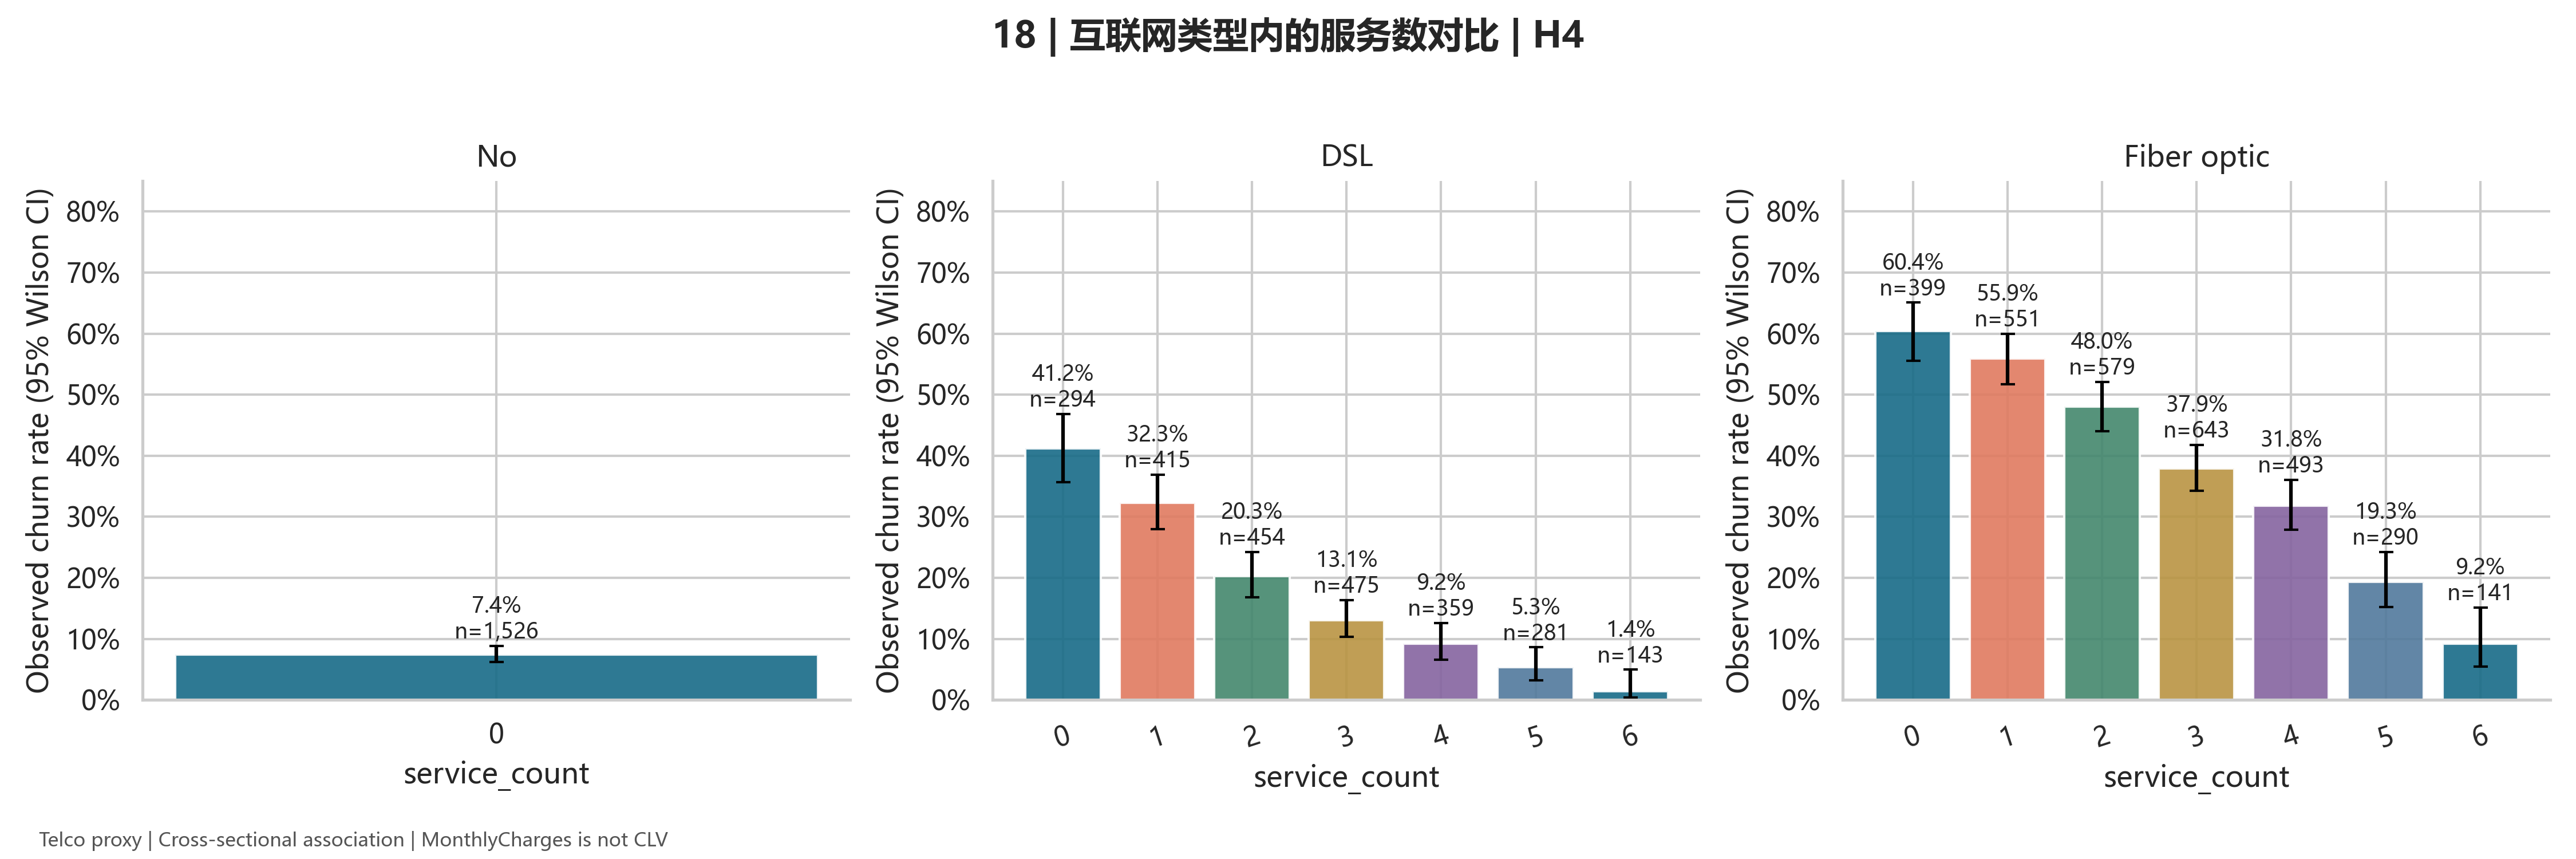

**结论：** 0服务客户在不同互联网类型中基线不同；分层后再判断服务数量方向。

**下一步：** 保留InternetService类别并对分层结果做敏感性核查。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_service_count_by_internet.csv`

In [20]:
chart = chart_index.loc[chart_index.chart_id.eq('18')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图19：合同×支付方式交叉流失率（H6,H1）

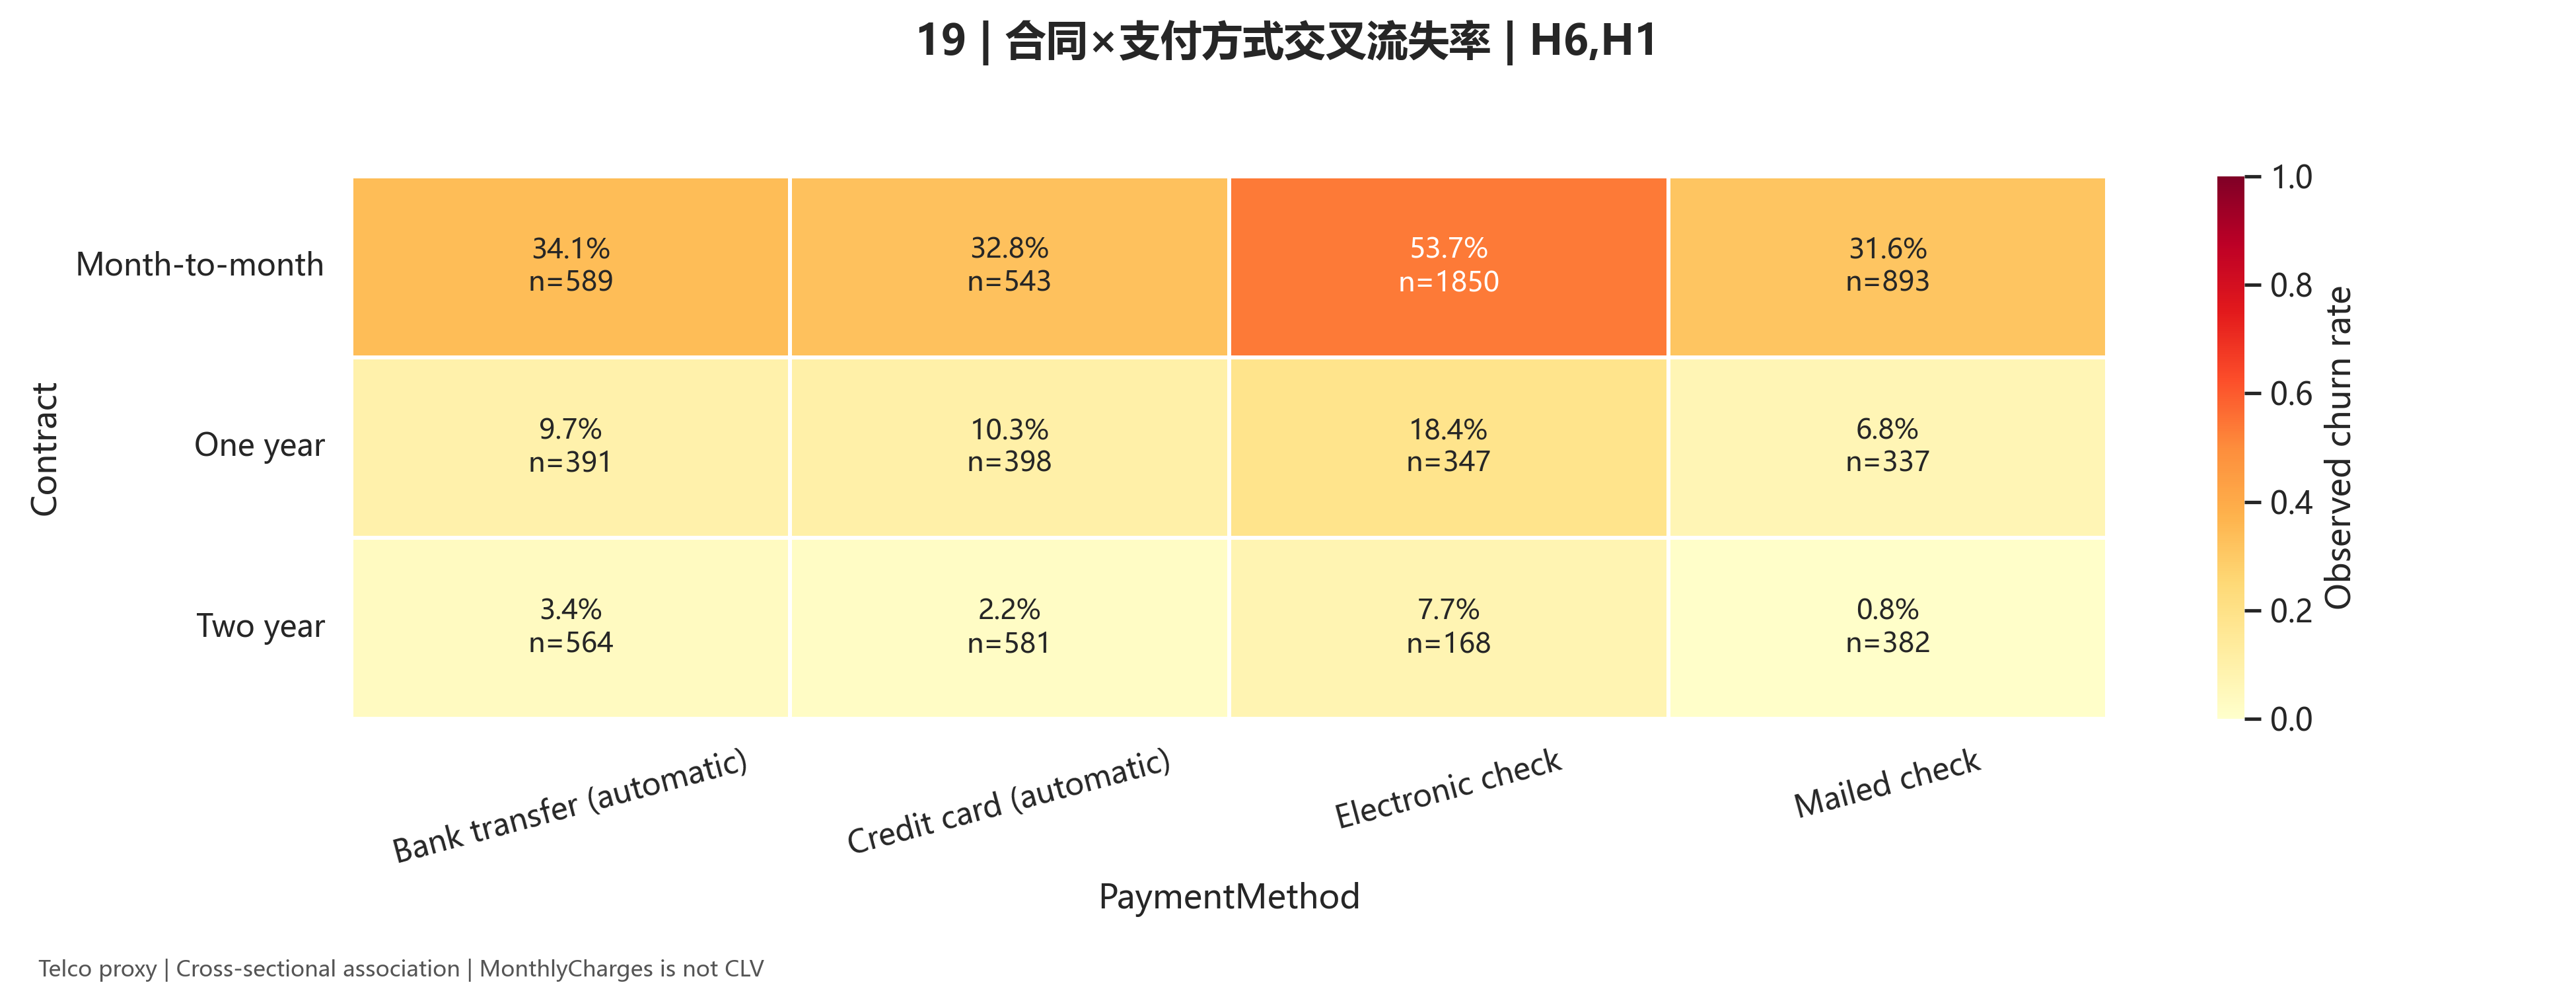

**结论：** 支付方式差异需要结合合同类型解读，各格样本量并不相同。

**下一步：** 将支付方式候选解释与合同构成共同复核。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_contract_payment_rates.csv`

In [21]:
chart = chart_index.loc[chart_index.chart_id.eq('19')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

### 图20：互联网客户常见增值服务组合（H4）

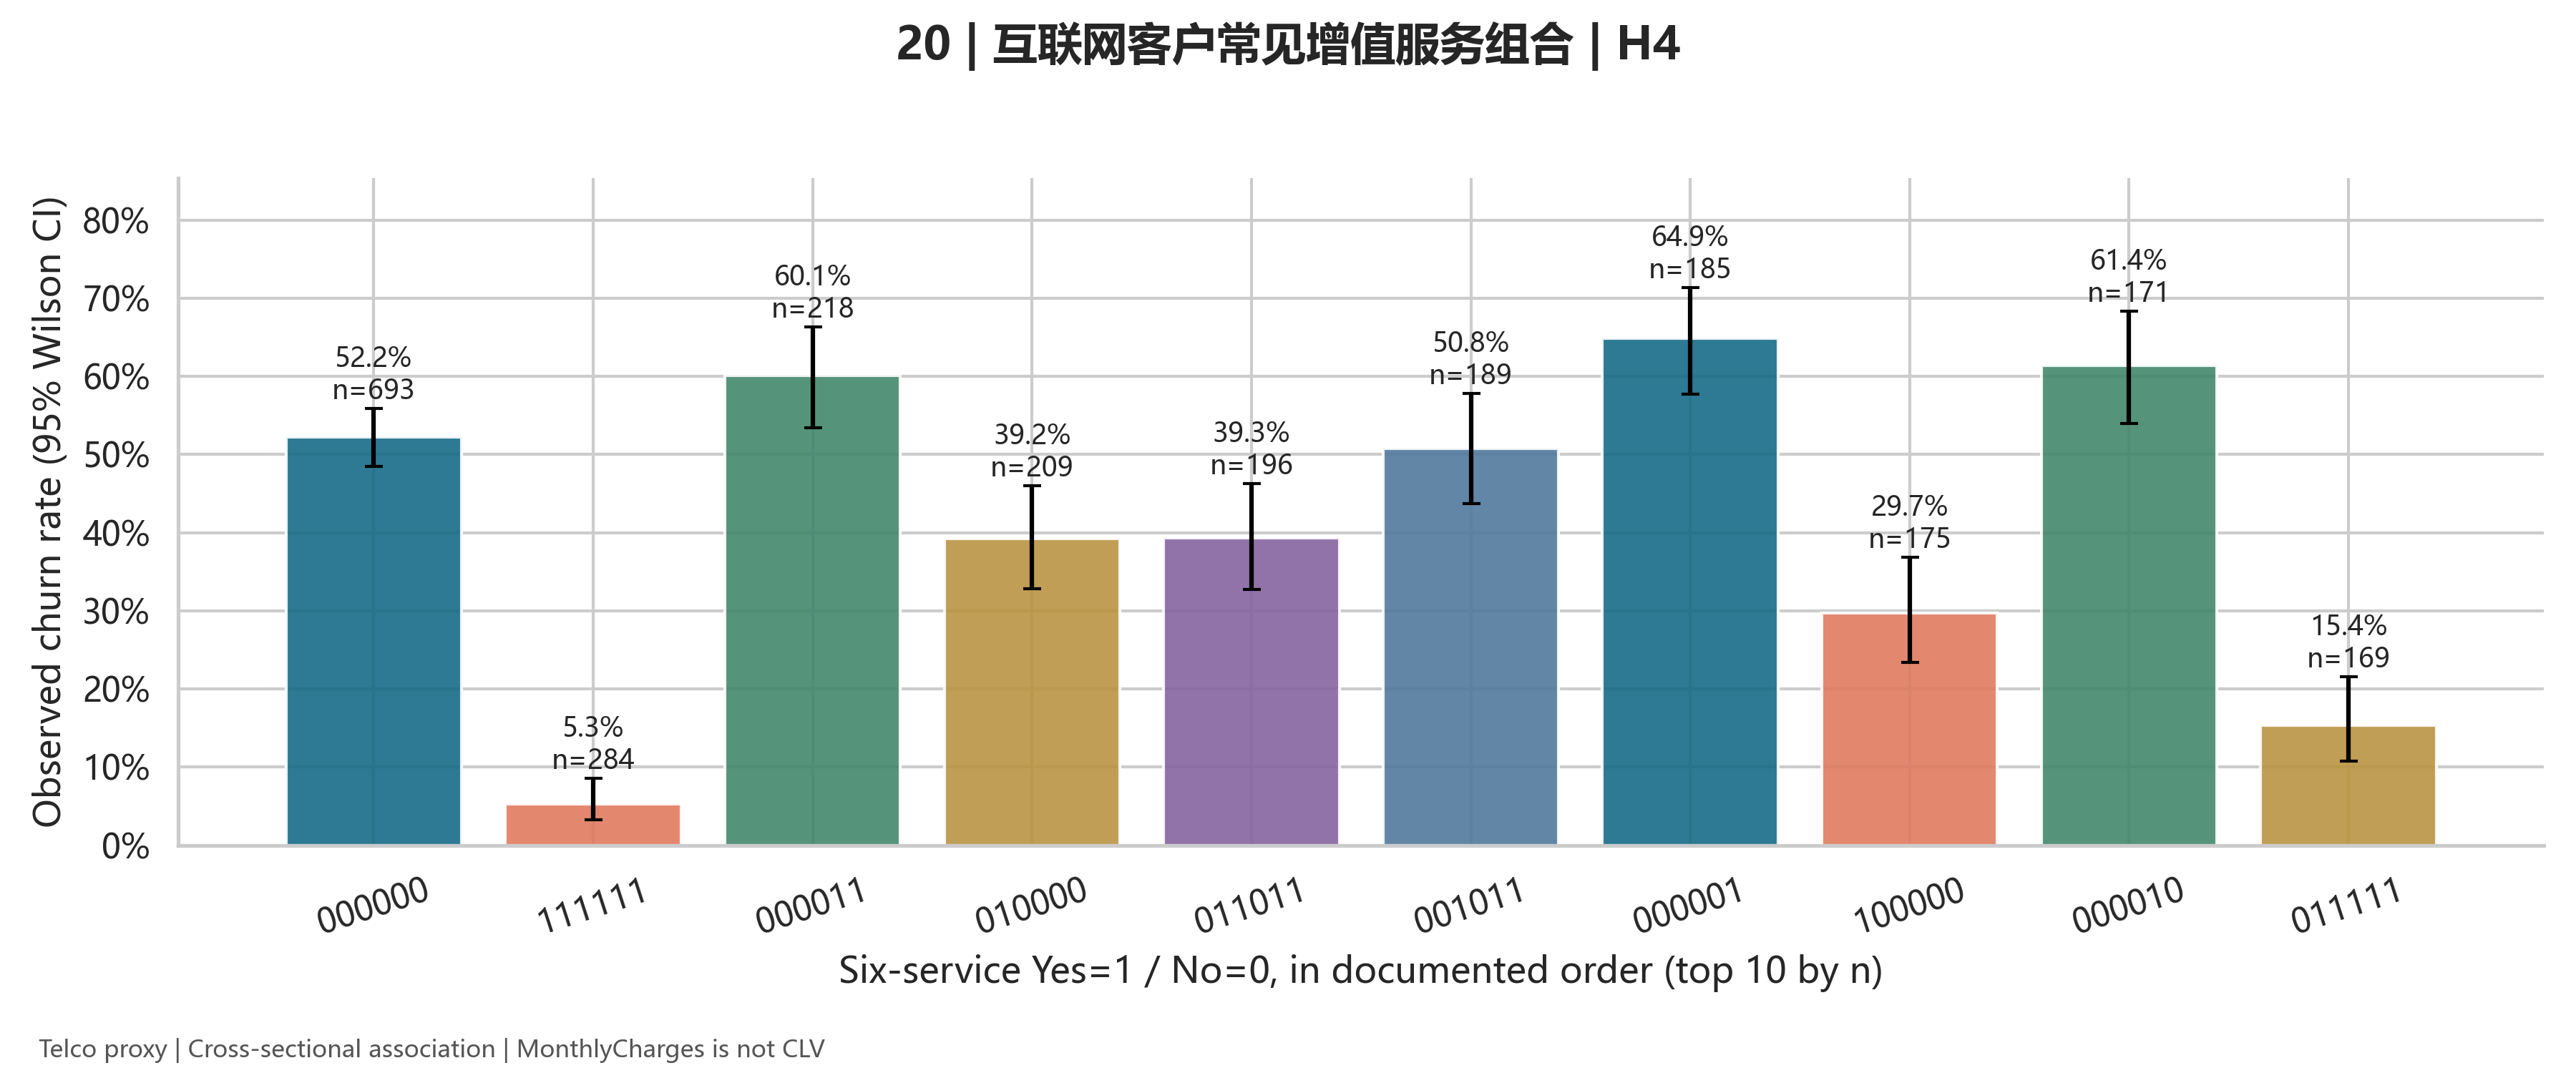

**结论：** 按样本量列出前十种组合，组合间差异是探索结果，未做独立确认检验。

**下一步：** 用组合分布支持需求访谈，不根据本图推荐强制加购。

**限制：** Telco公开代理数据；横截面关联；无事件日期；月费为价值代理，非CLV。

聚合证据：`reports/tables/w2_service_combinations.csv`

In [22]:
chart = chart_index.loc[chart_index.chart_id.eq('20')].iloc[0]
display(Markdown(f'### 图{chart.chart_id}：{chart.title}（{chart.hypothesis_id}）'))
display(Image(filename=str(PACKAGE / chart.path), width=1000))
display(Markdown(f'**结论：** {chart.conclusion}\n\n**下一步：** {chart.action}\n\n**限制：** {chart.limitations}'))
display(Markdown(f'聚合证据：`{chart.evidence}`'))

## 假设结果与限制

H1/H2支持预设方向；H4/H5/H6/H9/H10仅部分支持可观察命题。H1 p值为合同总体检验；H5高费DSL少服务仅3人，不足以作稳定结论；H10 p值仅对应费用分位与标签关联，不验证资源分配收益。

In [23]:
display(hypotheses[['hypothesis_id','status','conclusion','p_bonferroni','effect']])
display(result['tables']['w2_fee_service_by_internet'])
display(result['tables']['w2_risk_value_prototype'])

,hypothesis_id,status,conclusion,p_bonferroni,effect
0,H1,通过,合同类型与观察流失有关，月付组高于一年期与两年期。,3.517823e-257,0.410116
1,H2,通过,年限与标签负相关；低tenure组观察流失率更高。,8.427701e-223,-0.367062
2,H3,不可验证,缺登录、资源使用量及30–90天时间序列。,NaN,NaN
3,H4,部分通过,互联网客户内服务数与流失负相关；全体0服务组混杂无互联网客户，非简单全局单调关系。,5.372473e-105,-0.287901
4,H5,部分通过,高月费互联网客户中少服务组流失较高；光纤内方向一致，但DSL高费少服务组样本极少、校正不显著...,1.952404e-72,0.304883
5,H6,部分通过,手动与自动支付组观察流失不同，电子支票差异突出；支付失败无数据。,1.123495e-68,0.209902
6,H7,不可验证,不可验证：工单表无Telco customerID及可靠映射，Telco无快照时间；未合并。,NaN,NaN
7,H8,不可验证,沿用W1定义：自动续费与历史续约；缺自动续费标志、续约历史、到期日。,NaN,NaN
8,H9,部分通过,部分人口细分基线存在差异，性别无显著证据；未验证各群驱动权重差异。,3.791161e-36,0.150889
9,H10,部分通过,完成月费分位关联与风险规则×价值矩阵雏形；未证明资源分配效果。,6.825931e-77,0.226016


,InternetService,fee_level,service_level,n,churned,churn_rate,ci_low,ci_high,small_group
0,DSL,High fee,0-2 add-ons,3,1,0.333333,0.061492,0.792340,True
1,DSL,High fee,3-6 add-ons,580,34,0.058621,0.042250,0.080800,False
2,DSL,Low fee,0-2 add-ons,1160,346,0.298276,0.272649,0.325234,False
3,DSL,Low fee,3-6 add-ons,678,78,0.115044,0.093165,0.141261,False
4,Fiber optic,High fee,0-2 add-ons,1374,733,0.533479,0.507044,0.559727,False
5,Fiber optic,High fee,3-6 add-ons,1567,470,0.299936,0.277760,0.323091,False
6,Fiber optic,Low fee,0-2 add-ons,155,94,0.606452,0.527860,0.679894,False


,risk_rule,fee_level,n,churned,churn_rate,ci_low,ci_high,small_group,monthly_charge_sum,monthly_charge_mean,customer_share,monthly_charge_share
0,Other customers,High fee,3039,878,0.288911,0.273070,0.305284,False,279252.95,91.889750,0.431492,0.612240
1,Other customers,Low fee,2686,251,0.093448,0.083014,0.105043,False,103672.50,38.597357,0.381372,0.227294
2,Rule flagged,High fee,485,360,0.742268,0.701545,0.779184,False,39908.95,82.286495,0.068863,0.087497
3,Rule flagged,Low fee,833,380,0.456182,0.422637,0.490130,False,33282.20,39.954622,0.118273,0.072969


## W3 输入与验收

11 个 TotalCharges 空白与 tenure=0 重合，先核查业务规则再确定处理；保留 No internet service 的结构性含义。完整建议见 `reports/w2_to_w3_cleaning_recommendations.md`。H3缺使用序列，H7缺客户映射和时间，H8缺自动续费/续约历史。

In [24]:
display(result['tables']['w2_quality_observations'])
print(result['h7']['decision'])
assert len(chart_index) >= 15
assert hypotheses.analyzed.sum() >= 5
assert set(['H1','H2','H4','H10']).issubset(set(hypotheses.loc[hypotheses.analyzed,'hypothesis_id']))
assert all((PACKAGE / path).is_file() for path in chart_index.path)
assert result['metadata']['raw_unchanged']
print(f'完成：{len(chart_index)}张图，{int(hypotheses.analyzed.sum())}项完成分析并形成结论；原始数据哈希未改变。')

,check,value,interpretation
0,rows,7043,W1 baseline 7043
1,columns,21,W1 baseline 21
2,duplicate_customer_id,0,Must be zero
3,duplicate_rows,0,Must be zero
4,explicit_null_cells,0,Does not detect whitespace strings
5,total_charges_whitespace,11,Read-only audit; not converted or analyzed
6,tenure_zero,11,Retained in W2
7,blank_charges_and_zero_tenure,11,No automatic imputation decision
8,no_internet_customers,1526,Structural ineligibility is not missingness
9,addon_logic_conflicts,0,Across six service fields


不可验证：工单表无Telco customerID及可靠映射，Telco无快照时间；未合并。
完成：20张图，7项完成分析并形成结论；原始数据哈希未改变。
